# AI Analysis of Regenerative Braking in Urban Electric Vehicles

**CST7000 MSc Technology Dissertation — Analysis Notebook**

Md Amjad Hossain Khan | st20341331  
MSc Robotics and Artificial Intelligence  
Cardiff Metropolitan University  
Supervisor: Paul Jenkins

---

## What this notebook does

This notebook holds the full analysis behind my dissertation. It takes two standard driving cycles, works out how much braking energy each one makes available, estimates how much of that energy a real electric vehicle would actually recover, and then uses machine learning to identify which factors decide the size of the gap between the two.

Everything reported in Chapter 4 of the dissertation comes from the outputs of this notebook. I have kept the section order close to the order the work was actually done in, so it should read from top to bottom without jumping around.

## How the sections map onto the dissertation

| Section | What it covers | Dissertation chapter |
|---------|----------------|----------------------|
| 0 | Libraries and plot setup | — |
| 1 | Vehicle parameters | 3.3 |
| 2 | Loading the UDDS cycle | 3.3 |
| 3 | Loading the WLTP cycle | 3.3 |
| 4 | Classifying driving behaviour | 4.1 |
| 5 | Detecting braking events | 4.1 |
| 6 | Energy calculations | 4.2, 4.3 |
| 7 | Loss decomposition | 4.2, 4.3 |
| 8 | Comparing UDDS against WLTP | 4.4 |
| 9 | Stop-and-go versus smooth segments | 4.5 |
| 10 | Feature engineering | 4.6 |
| 11 | Model training and comparison | 4.6 |
| 12 | Summary of key numbers | 4.7 |
| 13 | Feature importance | 4.6 |
| 14 | Statistical validation | 4.6 |
| 15 | Figures | Chapter 4 figures |
| 16 | Exporting results | — |

## Running it

Run the cells in order from the top. Section 2 needs the EPA UDDS file uploaded first, and Section 3 installs the JRC `wltp` package if it is not already there. Everything after that runs without further input.

Code and outputs are also available at:  
https://github.com/Amjadkhan-CMU/Regenerative-Braking-Analysis-MSc


## Section 0: Setup

The standard scientific Python stack. NumPy and Pandas handle the data, SciPy covers the statistical tests, scikit-learn provides the regression models, and Matplotlib with Seaborn produce the figures.

I set the plot style once here rather than repeating it for every figure, so that everything saved out of this notebook looks consistent when the eight figures sit together in Chapter 4.


In [1]:
# Data handling and numerical work
import numpy as np
import pandas as pd
from scipy import stats
from scipy.ndimage import gaussian_filter1d
from scipy.signal import savgol_filter
import warnings
warnings.filterwarnings('ignore')

# Plotting
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

# Five models, so a good result is not down to one algorithm and evaluation
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline

# Saving outputs
import os
import json
from datetime import datetime

# Plot style, set once so all figures match
plt.rcParams.update({
    'figure.dpi': 150,
    'figure.facecolor': 'white',
    'axes.facecolor': '#fafafa',
    'axes.grid': True,
    'grid.alpha': 0.35,
    'grid.linestyle': '--',
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'lines.linewidth': 1.5,
    'savefig.bbox': 'tight',
    'savefig.dpi': 300
})

# Folders for saved figures and data
os.makedirs('outputs', exist_ok=True)
os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('outputs/data', exist_ok=True)

print("All libraries loaded successfully.")
print(f"NumPy {np.__version__} | Pandas {pd.__version__}")
print(f"Outputs will be saved to: outputs/figures/ and outputs/data/")


All libraries loaded successfully.
NumPy 2.0.2 | Pandas 2.2.2
Outputs will be saved to: outputs/figures/ and outputs/data/


## Section 1: Vehicle Parameters

The simulated vehicle is a compact urban battery electric vehicle based on the published specifications of the second-generation Nissan Leaf. I chose one well-documented vehicle deliberately, because it means any difference between the two driving cycles can be put down to the driving conditions rather than to differences in the car.

Every value below comes either from the manufacturer specification or from a published paper. The same table appears as Table 2 in the dissertation.

| Parameter | Value | Where it comes from |
|-----------|-------|---------------------|
| Kerb mass | 1521 kg | Manufacturer specification |
| Peak motor efficiency | 0.92 | Szumska (2025) |
| Inverter efficiency | 0.97 | He et al. (2022) |
| Battery charging efficiency | 0.95 | Chidambaram et al. (2023) |
| Friction braking threshold | 0.3g | He et al. (2022) |
| SOC upper limit for regeneration | 95% | Zu et al. (2024) |
| Minimum regeneration speed | 10 km/h | Szumska and Skuza (2025) |

The three efficiencies multiply to a combined drivetrain efficiency of 0.8482. That is the best case, before any of the constraints in Section 6 are applied.


In [2]:
# Nissan Leaf 2nd gen, used as the representative urban BEV
VP = {
    # Physical properties
    'mass_kg'               : 1521,      # kerb mass, kg
    'frontal_area_m2'       : 2.27,      # frontal area, m²
    'drag_coeff'            : 0.28,      # aerodynamic drag coefficient Cd
    'rolling_resist'        : 0.011,     # rolling resistance coefficient Cr
    'gravity_ms2'           : 9.81,      # gravitational acceleration, m/s²
    # Drivetrain efficiencies (Szumska 2025; He et al. 2022)
    'eta_motor'             : 0.92,      # motor/generator efficiency
    'eta_inverter'          : 0.97,      # power electronics efficiency
    'eta_battery'           : 0.95,      # battery round-trip charging efficiency
    # Limits on when regeneration can happen
    'friction_threshold_g'  : 0.30,      # decel above this -> friction brakes engage (He et al., 2022)
    'soc_upper'             : 0.95,      # regen disabled above this SOC (Zu et al., 2024)
    'soc_lower'             : 0.20,      # reduced regen below this SOC
    'min_regen_speed_ms'    : 2.78,      # 10 km/h — minimum speed for effective regen
    # Battery
    'battery_capacity_kWh'  : 40.0,      # usable battery capacity
    'soc_initial'           : 0.80,      # starting SOC for simulation
    'soc_final_target'      : 0.25,      # approximate final SOC after urban trip
}

# Multiply the three efficiencies together: best case before constraints
VP['eta_drivetrain'] = VP['eta_motor'] * VP['eta_inverter'] * VP['eta_battery']
VP['friction_threshold_ms2'] = VP['friction_threshold_g'] * VP['gravity_ms2']

print("Vehicle Parameters Confirmed:")
print(f"  Mass                : {VP['mass_kg']} kg")
print(f"  Drivetrain eta      : {VP['eta_drivetrain']:.4f}  ({VP['eta_drivetrain']*100:.2f}%)")
print(f"  Friction threshold  : {VP['friction_threshold_ms2']:.3f} m/s²  ({VP['friction_threshold_g']}g)")
print(f"  SOC window          : {VP['soc_lower']*100:.0f}% to {VP['soc_upper']*100:.0f}%")
print(f"  Min regen speed     : {VP['min_regen_speed_ms']:.2f} m/s  ({VP['min_regen_speed_ms']*3.6:.1f} km/h)")


Vehicle Parameters Confirmed:
  Mass                : 1521 kg
  Drivetrain eta      : 0.8478  (84.78%)
  Friction threshold  : 2.943 m/s²  (0.3g)
  SOC window          : 20% to 95%
  Min regen speed     : 2.78 m/s  (10.0 km/h)


## Section 2: Loading the UDDS Cycle

The Urban Dynamometer Driving Schedule is the standard US urban cycle. It runs for 1370 seconds with frequent stops and speed changes, which is exactly the kind of driving where regenerative braking should matter most.

I downloaded the official speed trace from the EPA rather than using an approximation, so anyone with the same file can reproduce the analysis:  
https://www.epa.gov/vehicle-and-fuel-emissions-testing/dynamometer-drive-schedules

The file is `udds.txt`, tab separated, with two header rows and two columns holding time in seconds and speed in miles per hour. The first cell below uploads it into Colab, the second reads it and converts to metres per second.

A Savitzky-Golay filter (window 5, polynomial order 2) is applied to the speed trace. It smooths the small numerical steps in the raw data without flattening the shape of the braking events, which matters because the next stage detects those events from the gradient of this signal (Savitzky and Golay, 1964).


In [3]:
# Upload the EPA UDDS file into Colab
# Run this before the loading cell below

import os
from google.colab import files

os.makedirs("data", exist_ok=True)

print("A file picker will appear below.")
print("Select your udds.txt file from your computer.")
print()

uploaded = files.upload()

for filename, content in uploaded.items():
    save_path = f"data/udds.txt"
    with open(save_path, "wb") as f:
        f.write(content)
    print(f"Saved to: {save_path}")
    print("Now run the UDDS cell.")

A file picker will appear below.
Select your udds.txt file from your computer.



Saving udds.txt.txt to udds.txt.txt
Saved to: data/udds.txt
Now run the UDDS cell.


In [4]:
# Read the EPA UDDS file and convert units

# File: data/udds.txt
# Source: U.S. Environmental Protection Agency (EPA)
# Format: Tab-separated, 2 header rows, columns: time(s) | speed(mph)

import os
from scipy.signal import savgol_filter

UDDS_FILE = "data/udds.txt"

if not os.path.exists(UDDS_FILE):
    raise FileNotFoundError(
        "\nUDDS file not found."
        "\nDownload from: https://www.epa.gov/vehicle-and-fuel-emissions-testing/dynamometer-drive-schedules"
        "\nSave as: data/udds.txt next to this notebook"
    )

# Read file — skip 2 header rows, tab-separated
raw = pd.read_csv(
    UDDS_FILE,
    sep="\t",
    skiprows=2,
    header=None,
    names=["time_s", "speed_mph"],
    engine="python"
)

# Keep numeric rows only
raw = raw[pd.to_numeric(raw["time_s"], errors="coerce").notna()]
raw = raw.astype(float).reset_index(drop=True)

# Assemble into a DataFrame
udds = pd.DataFrame({
    "time_s"    : raw["time_s"].values,
    "speed_mph" : raw["speed_mph"].values
})
udds["speed_ms"]  = savgol_filter(
    (udds["speed_mph"] * 0.44704).clip(lower=0), 5, 2
).clip(min=0)
udds["speed_kmh"] = udds["speed_mph"] * 1.60934
udds["cycle"]     = "UDDS"

print("UDDS loaded successfully [EPA Official File]")
print(f"  Data points : {len(udds)}")
print(f"  Duration    : {len(udds)} s  ({len(udds)/60:.1f} min)")
print(f"  Max speed   : {udds.speed_mph.max():.1f} mph  /  {udds.speed_ms.max():.2f} m/s")
print(f"  Avg speed   : {udds.speed_mph.mean():.2f} mph")
print(f"  Stopped     : {(udds.speed_ms < 0.5).mean()*100:.1f}% of time")

UDDS loaded successfully [EPA Official File]
  Data points : 1370
  Duration    : 1370 s  (22.8 min)
  Max speed   : 56.7 mph  /  25.35 m/s
  Avg speed   : 19.58 mph
  Stopped     : 20.0% of time


## Section 3: Loading the WLTP Cycle

The Worldwide Harmonised Light Vehicles Test Procedure replaced the older NEDC in Europe and covers a much wider range of driving than the UDDS, from slow urban traffic up to motorway speeds. Running it alongside the UDDS is what lets me test whether the energy recovery gap is specific to city driving or holds across quite different conditions.

I use Class 3b because it applies to vehicles with a power-to-mass ratio above 34 kW per tonne, which covers the Nissan Leaf modelled here.

Rather than building the trace myself, I load it from the `wltp` package maintained by the European Commission Joint Research Centre. That package implements the exact trace given in UNECE Regulation No. 154 Annex 1, so there is no approximation error and the cycle is fully reproducible.

**On the installation step.** Colab does not ship with the `wltp` package, so the code below tries to import it first and only runs `pip install` if that import fails. That keeps the notebook self-contained. Because Colab resets between sessions, the install will run again in each fresh runtime. That is expected and does not affect the results.

### The four WLTP Class 3b phases

| Phase | Time range | Duration | Max speed | Avg speed | Driving type |
|-------|-----------|----------|-----------|-----------|--------------|
| Low | 0 to 589 s | 589 s | 56.5 km/h | 18.9 km/h | Urban stop-and-go |
| Medium | 589 to 1022 s | 433 s | 76.6 km/h | 39.4 km/h | Suburban |
| High | 1022 to 1477 s | 455 s | 97.4 km/h | 56.5 km/h | Rural |
| Extra-High | 1477 to 1800 s | 323 s | 131.3 km/h | 91.7 km/h | Motorway |

The printed output checks the loaded cycle against the published maximum of 131.3 km/h and average of 46.5 km/h, so I can confirm the right data came through.


In [7]:
# Official WLTP Class 3b trace from the JRC wltp package
# UNECE Regulation No. 154
# https://pypi.org/project/wltp/

import subprocess, sys

try:
    import wltp.cycles.class3 as class3
except ModuleNotFoundError:
    print("Installing wltp package...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "wltp", "-q"])
    import wltp.cycles.class3 as class3
# Pull the Class 3b cycle as specified in UNECE Reg. 154
data_b = class3.class_data_b()
cycle_speeds = np.array(data_b['cycle'])

n = len(cycle_speeds)
wltp = pd.DataFrame({
    "time_s": np.arange(n),
    "speed_kmh": cycle_speeds
})
wltp["speed_kmh"] = wltp["speed_kmh"].clip(lower=0)
wltp["speed_ms"] = wltp["speed_kmh"] / 3.6
wltp["speed_mph"] = wltp["speed_kmh"] * 0.62137
wltp["cycle"] = "WLTP"

# Label the four phases using the official time boundaries
boundaries = [0, 589, 1022, 1477, 1800]
phase_names = ["Low", "Medium", "High", "Extra-High"]
phase_arr = np.empty(len(wltp), dtype=object)
for name, start, end in zip(phase_names, boundaries[:-1], boundaries[1:]):
    phase_arr[start:end] = name
wltp["phase"] = phase_arr

print(f"WLTP loaded (JRC wltp package): {len(wltp)} points")
print(f"Max speed: {wltp.speed_kmh.max():.1f} km/h  [spec: 131.3]")
print(f"Avg speed: {wltp.speed_kmh.mean():.1f} km/h  [spec: 46.5]")

Installing wltp package...
WLTP loaded (JRC wltp package): 1801 points
Max speed: 131.3 km/h  [spec: 131.3]
Avg speed: 46.5 km/h  [spec: 46.5]


## Section 4: Classifying Driving Behaviour

Before picking out individual braking events, it helps to see how each cycle divides up overall. At every second I classify the vehicle into one of four states, and separately flag whether that second is eligible for regeneration.

| State | Condition |
|-------|-----------|
| Braking | Acceleration below -0.10 m/s2 |
| Accelerating | Acceleration above +0.10 m/s2 |
| Cruising | Moving, but neither braking nor accelerating |
| Stopped | Speed below 0.5 m/s |
| Regeneration eligible | Braking and speed above 2.78 m/s |

The 0.10 m/s2 threshold keeps genuine deceleration separate from the small fluctuations that come out of numerically differentiating a speed trace. The 2.78 m/s floor is the speed below which regeneration stops being effective (Szumska and Skuza, 2025).

This answers a practical question before any energy is calculated: how much of each cycle is even available for recovery in the first place.


In [8]:
def classify_behaviour(df):
    df = df.copy()
    df['accel_ms2']        = np.gradient(df['speed_ms'].values, df['time_s'].values)
    df['accel_ms2']        = savgol_filter(df['accel_ms2'], 5, 2)
    df['jerk_ms3']         = np.gradient(df['accel_ms2'].values, df['time_s'].values)
    df['is_braking']       = df['accel_ms2'] < -0.10
    df['is_accelerating']  = df['accel_ms2'] >  0.10
    df['is_cruising']      = (~df['is_braking']) & (~df['is_accelerating']) & (df['speed_ms'] > 0.5)
    df['is_stopped']       = df['speed_ms'] < 0.5
    df['is_regen_eligible']= df['is_braking'] & (df['speed_ms'] > VP['min_regen_speed_ms'])
    return df

udds = classify_behaviour(udds)
wltp = classify_behaviour(wltp)

print("Driving Behaviour Summary")
print(f"{'Metric':<35} {'UDDS':>10} {'WLTP':>10}")
print("-"*58)
for label, col in [
    ('Braking (%)',          'is_braking'),
    ('Accelerating (%)',     'is_accelerating'),
    ('Cruising (%)',         'is_cruising'),
    ('Stopped (%)',          'is_stopped'),
    ('Regen eligible (%)',   'is_regen_eligible'),
]:
    u = udds[col].mean()*100
    w = wltp[col].mean()*100
    print(f"  {label:<33} {u:>9.2f} {w:>9.2f}")

print(f"\n  {'Max deceleration (m/s2)':<33} {udds.accel_ms2.min():>9.3f} {wltp.accel_ms2.min():>9.3f}")
print(f"  {'Max acceleration (m/s2)':<33} {udds.accel_ms2.max():>9.3f} {wltp.accel_ms2.max():>9.3f}")


Driving Behaviour Summary
Metric                                    UDDS       WLTP
----------------------------------------------------------
  Braking (%)                           28.47     32.82
  Accelerating (%)                      34.53     35.26
  Cruising (%)                          20.80     19.54
  Stopped (%)                           20.00     13.88
  Regen eligible (%)                    23.80     30.59

  Max deceleration (m/s2)              -1.549    -1.529
  Max acceleration (m/s2)               1.545     1.569


## Section 5: Detecting Braking Events

The energy analysis works on discrete braking events rather than individual seconds, so this section groups consecutive decelerating seconds into events.

An event starts when deceleration passes -0.10 m/s2 while the vehicle is above the minimum regeneration speed, and ends when the deceleration eases off or the speed drops below that threshold. I require a minimum of two seconds, which filters out momentary dips that are not really braking.

For each event I record the initial and final speed, duration, peak and average deceleration, and the kinetic energy available. Those values feed straight into the energy model in Section 6 and later become the features for the machine learning in Section 10.


In [9]:
def detect_braking_events(df, cycle_name):
    events = []
    in_brake = False
    start_idx = None

    speed  = df['speed_ms'].values
    accel  = df['accel_ms2'].values
    time   = df['time_s'].values

    for i in range(1, len(df)-1):
        if not in_brake:
            if accel[i] < -0.10 and speed[i] > VP['min_regen_speed_ms']:
                in_brake  = True
                start_idx = i
        else:
            if accel[i] >= -0.04 or speed[i] <= VP['min_regen_speed_ms'] or i == len(df)-2:
                end_idx = i
                dur     = end_idx - start_idx
                if dur >= 2:
                    seg    = df.iloc[start_idx:end_idx]
                    v_i    = speed[start_idx]
                    v_f    = speed[end_idx]
                    e_k    = 0.5 * VP['mass_kg'] * max(0, v_i**2 - v_f**2)
                    p_dec  = accel[start_idx:end_idx].min()
                    a_dec  = accel[start_idx:end_idx].mean()
                    if e_k > 0:
                        events.append({
                            'cycle'           : cycle_name,
                            'event_id'        : len(events)+1,
                            'start_time_s'    : time[start_idx],
                            'end_time_s'      : time[end_idx],
                            'duration_s'      : dur,
                            'v_initial_ms'    : v_i,
                            'v_final_ms'      : v_f,
                            'v_initial_kmh'   : v_i * 3.6,
                            'v_final_kmh'     : v_f * 3.6,
                            'delta_v_ms'      : v_i - v_f,
                            'peak_decel_ms2'  : abs(p_dec),
                            'avg_decel_ms2'   : abs(a_dec),
                            'e_kinetic_J'     : e_k,
                            'e_kinetic_Wh'    : e_k / 3600,
                        })
                in_brake = False

    return pd.DataFrame(events)

udds_events = detect_braking_events(udds, 'UDDS')
wltp_events = detect_braking_events(wltp, 'WLTP')

print("Braking Event Detection Results")
print(f"{'Metric':<40} {'UDDS':>10} {'WLTP':>10}")
print("-"*63)
for label, fn in [
    ('Total events detected',         lambda d: len(d)),
    ('Total KE available (Wh)',        lambda d: round(d.e_kinetic_Wh.sum(),2)),
    ('Mean event duration (s)',        lambda d: round(d.duration_s.mean(),2)),
    ('Mean initial speed (km/h)',      lambda d: round(d.v_initial_kmh.mean(),2)),
    ('Mean peak decel (m/s2)',         lambda d: round(d.peak_decel_ms2.mean(),3)),
    ('Mean KE per event (Wh)',         lambda d: round(d.e_kinetic_Wh.mean(),3)),
]:
    print(f"  {label:<38} {fn(udds_events):>10} {fn(wltp_events):>10}")


Braking Event Detection Results
Metric                                         UDDS       WLTP
---------------------------------------------------------------
  Total events detected                          45         54
  Total KE available (Wh)                     803.8    1423.81
  Mean event duration (s)                      7.76      10.85
  Mean initial speed (km/h)                   45.26      51.66
  Mean peak decel (m/s2)                      0.787      0.867
  Mean KE per event (Wh)                     17.862     26.367


## Section 6: Energy Calculations

This is the core of the analysis. For each braking event I work out two numbers: how much energy was theoretically available, and how much a real vehicle would actually get back.

### Recoverable energy

The energy available is the change in kinetic energy across the event:

    E_recoverable = 0.5 x m x (v_i^2 - v_f^2)

where m is vehicle mass and v_i and v_f are the speeds at the start and end.

### Recovered energy

    E_recovered = E_recoverable x eta_motor x eta_inverter x eta_battery x f_constraints

### Why motor efficiency is not a fixed number

The decision I am least willing to compromise on is treating motor efficiency as dependent on how hard the vehicle is braking, rather than fixing it at peak.

Real motors work across a wide torque-speed envelope and their efficiency falls away when they operate far from the peak region of the efficiency map. Very gentle braking puts the motor in exactly that unfavourable corner. Holding efficiency at 0.92 would quietly assume otherwise, and would have produced an identical recovery rate for every event, which is not what happens in practice (He et al., 2022; Sandrini et al., 2022).

| Deceleration ratio (relative to 0.3g) | Motor efficiency applied |
|---------------------------------------|--------------------------|
| Below 0.15 (very light braking) | 70% of peak (0.644) |
| 0.15 to 0.30 | 82% of peak (0.754) |
| 0.30 to 0.50 | 90% of peak (0.828) |
| 0.50 to 0.80 | 96% of peak (0.883) |
| 0.80 to 1.00 (near friction limit) | 100% of peak (0.920) |
| Above 1.00 | Reduced by regenerative share |

### The constraint factor

Four further constraints sit on top of motor efficiency:

1. **State of charge.** Regeneration is disabled above 95% SOC and reduced below 20% (Zu et al., 2024). I taper both limits rather than switching them abruptly.
2. **Friction braking threshold.** Above 0.3g the friction brakes progressively take over and the regenerative share falls (He et al., 2022).
3. **Speed.** Recovery becomes less effective at low speed and is heavily reduced below 10 km/h.
4. **Event duration.** Very short events lose extra energy to transient motor response.

SOC is modelled as depleting linearly from 80% to 25% across each cycle. That is a simplification, and I say so in the dissertation limitations, but it is a conservative one and consistent with how Zu et al. (2024) handled the same problem in simulation.

### Loss decomposition

The gap for each event is then split into four parts: motor, inverter, battery, and constraint losses. That split is what answers Research Question 3, because it shows where the energy goes rather than only how much is missing.


In [10]:
def calculate_energy_recovery(events_df):
    df = events_df.copy()
    n  = len(df)

    # SOC profile
    soc_profile = np.linspace(VP['soc_initial'], VP['soc_final_target'], n)
    df['soc'] = soc_profile

    constraint_factors = []

    for idx, (_, row) in enumerate(df.iterrows()):
        f = 1.0
        soc = soc_profile[idx]

        # SOC upper constraint
        if soc >= VP['soc_upper']:
            f = 0.0
        elif soc >= 0.90:
            # Gradual reduction approaching upper limit
            f *= 1.0 - ((soc - 0.90) / (VP['soc_upper'] - 0.90)) * 0.5
        elif soc <= VP['soc_lower']:
            f = 0.30
        elif soc <= 0.30:
            # Gradual reduction approaching lower limit
            f *= 0.30 + (soc - VP['soc_lower']) / (0.30 - VP['soc_lower']) * 0.70

        # Motor efficiency varies with deceleration intensity
        # At low decel, motor operates away from peak efficiency
        decel = row['peak_decel_ms2']
        decel_ratio = decel / VP['friction_threshold_ms2']

        if decel_ratio < 0.15:
            # Very light braking — motor efficiency drops significantly
            motor_eff = VP['eta_motor'] * 0.70
        elif decel_ratio < 0.30:
            motor_eff = VP['eta_motor'] * 0.82
        elif decel_ratio < 0.50:
            motor_eff = VP['eta_motor'] * 0.90
        elif decel_ratio < 0.80:
            motor_eff = VP['eta_motor'] * 0.96
        elif decel_ratio <= 1.0:
            motor_eff = VP['eta_motor'] * 1.00
        else:
            # Above friction threshold — friction brakes take share
            regen_share = max(0.0, 1.0 - (decel - VP['friction_threshold_ms2']) / VP['friction_threshold_ms2'])
            motor_eff = VP['eta_motor'] * regen_share
            f *= regen_share

        # Regeneration is weak at low speed — efficiency drops at low speed
        v = row['v_initial_ms']
        if v < VP['min_regen_speed_ms']:
            f *= 0.30
        elif v < 5.0:
            f *= 0.60
        elif v < 8.0:
            f *= 0.80

        # Very short events lose extra energy to transient response — very short events lose more
        dur = row['duration_s']
        if dur <= 2:
            f *= 0.70
        elif dur <= 4:
            f *= 0.85

        # Combined efficiency for this event
        eta_event = motor_eff * VP['eta_inverter'] * VP['eta_battery'] * f
        constraint_factors.append({
            'constraint_factor' : f,
            'eta_event'         : eta_event,
            'motor_eff_actual'  : motor_eff,
            'decel_ratio'       : decel_ratio,
        })

    cf_df = pd.DataFrame(constraint_factors, index=df.index)
    df = pd.concat([df, cf_df], axis=1)

    df['e_recoverable_J']     = df['e_kinetic_J']
    df['e_recoverable_Wh']    = df['e_kinetic_J'] / 3600
    df['e_recovered_J']       = df['e_kinetic_J'] * df['eta_event']
    df['e_recovered_Wh']      = df['e_recovered_J'] / 3600
    df['e_gap_J']             = df['e_recoverable_J'] - df['e_recovered_J']
    df['e_gap_Wh']            = df['e_gap_J'] / 3600
    df['recovery_rate_pct']   = (df['e_recovered_J'] / df['e_recoverable_J']).clip(0, 1) * 100
    df['gap_pct']             = 100.0 - df['recovery_rate_pct']

    # Split the gap into motor, inverter, battery and constraint losses
    df['loss_motor_Wh']       = df['e_recoverable_Wh'] * (1.0 - df['motor_eff_actual'])
    df['loss_inverter_Wh']    = df['e_recoverable_Wh'] * df['motor_eff_actual'] * (1.0 - VP['eta_inverter'])
    df['loss_battery_Wh']     = df['e_recoverable_Wh'] * df['motor_eff_actual'] * VP['eta_inverter'] * (1.0 - VP['eta_battery'])
    df['loss_constraints_Wh'] = (df['e_gap_Wh'] - df['loss_motor_Wh'] - df['loss_inverter_Wh'] - df['loss_battery_Wh']).clip(lower=0)

    return df

# Recalculate
udds_results = calculate_energy_recovery(udds_events)
wltp_results = calculate_energy_recovery(wltp_events)

# Quick check
print("Recovery rate variety check:")
print(f"  UDDS unique recovery rates : {udds_results['recovery_rate_pct'].nunique()}")
print(f"  UDDS min recovery rate     : {udds_results['recovery_rate_pct'].min():.2f}%")
print(f"  UDDS max recovery rate     : {udds_results['recovery_rate_pct'].max():.2f}%")
print(f"  UDDS mean recovery rate    : {udds_results['recovery_rate_pct'].mean():.2f}%")
print(f"  UDDS std recovery rate     : {udds_results['recovery_rate_pct'].std():.2f}%")
print(f"\n  WLTP unique recovery rates : {wltp_results['recovery_rate_pct'].nunique()}")
print(f"  WLTP mean recovery rate    : {wltp_results['recovery_rate_pct'].mean():.2f}%")

Recovery rate variety check:
  UDDS unique recovery rates : 13
  UDDS min recovery rate     : 22.74%
  UDDS max recovery rate     : 81.39%
  UDDS mean recovery rate    : 62.45%
  UDDS std recovery rate     : 16.48%

  WLTP unique recovery rates : 18
  WLTP mean recovery rate    : 63.68%


## Section 7: Loss Decomposition

The same four loss components again, this time as a percentage of total recoverable energy for each cycle. Percentages make the two cycles directly comparable even though they carry very different absolute energy quantities.

These figures produce the pie charts in Figure 4 of the dissertation.


In [11]:
def loss_breakdown_pct(df, name):
    total = df['e_recoverable_Wh'].sum()
    motor  = df['loss_motor_Wh'].sum()
    inv    = df['loss_inverter_Wh'].sum()
    bat    = df['loss_battery_Wh'].sum()
    const  = df['loss_constraints_Wh'].sum()
    recov  = df['e_recovered_Wh'].sum()

    print(f"\n{name} Loss Breakdown (% of total recoverable energy):")
    print(f"  Motor losses       : {motor/total*100:6.2f}%  ({motor:.3f} Wh)")
    print(f"  Inverter losses    : {inv/total*100:6.2f}%  ({inv:.3f} Wh)")
    print(f"  Battery losses     : {bat/total*100:6.2f}%  ({bat:.3f} Wh)")
    print(f"  Constraint losses  : {const/total*100:6.2f}%  ({const:.3f} Wh)")
    print(f"  Actually recovered : {recov/total*100:6.2f}%  ({recov:.3f} Wh)")
    print(f"  Total gap          : {(total-recov)/total*100:6.2f}%")

    return {
        'cycle': name, 'total_Wh': total,
        'motor_pct': motor/total*100, 'inverter_pct': inv/total*100,
        'battery_pct': bat/total*100, 'constraint_pct': const/total*100,
        'recovered_pct': recov/total*100, 'gap_pct': (total-recov)/total*100
    }

udds_loss = loss_breakdown_pct(udds_results, 'UDDS')
wltp_loss = loss_breakdown_pct(wltp_results, 'WLTP')
loss_df   = pd.DataFrame([udds_loss, wltp_loss])



UDDS Loss Breakdown (% of total recoverable energy):
  Motor losses       :  17.62%  (141.622 Wh)
  Inverter losses    :   2.47%  (19.865 Wh)
  Battery losses     :   4.00%  (32.116 Wh)
  Constraint losses  :   2.03%  (16.336 Wh)
  Actually recovered :  73.88%  (593.864 Wh)
  Total gap          :  26.12%

WLTP Loss Breakdown (% of total recoverable energy):
  Motor losses       :  20.04%  (285.361 Wh)
  Inverter losses    :   2.40%  (34.153 Wh)
  Battery losses     :   3.88%  (55.215 Wh)
  Constraint losses  :   7.24%  (103.064 Wh)
  Actually recovered :  66.44%  (946.013 Wh)
  Total gap          :  33.56%


## Section 8: Comparing UDDS Against WLTP

The two cycles are compared statistically here rather than by eye.

I use the Mann-Whitney U test rather than a t-test, because with these sample sizes I cannot safely assume the recovery rates are normally distributed, and Mann-Whitney does not require that. Cohen's d gives the effect size, which matters because a p-value tells you whether a difference exists but not whether it is large enough to care about.

The Shapiro-Wilk test at the top confirms whether the normality assumption holds, which is what justifies the choice of test in the first place.


In [12]:
# Mann-Whitney U: non-parametric, so no normality assumption needed
from scipy.stats import mannwhitneyu, ttest_ind, shapiro

u_rates = udds_results['recovery_rate_pct'].values
w_rates = wltp_results['recovery_rate_pct'].values

# Check normality first, this justifies using Mann-Whitney
_, p_norm_u = shapiro(u_rates[:50])  # Shapiro-Wilk on sample
_, p_norm_w = shapiro(w_rates[:50])

print("Normality Check (Shapiro-Wilk):")
print(f"  UDDS: p = {p_norm_u:.4f}  {'Normal' if p_norm_u > 0.05 else 'Non-normal'}")
print(f"  WLTP: p = {p_norm_w:.4f}  {'Normal' if p_norm_w > 0.05 else 'Non-normal'}")

# The test itself
stat_mw, p_mw = mannwhitneyu(u_rates, w_rates, alternative='two-sided')
print(f"\nMann-Whitney U Test:")
print(f"  U statistic : {stat_mw:.2f}")
print(f"  p-value     : {p_mw:.6f}")
print(f"  Significant : {'YES (p < 0.05)' if p_mw < 0.05 else 'NO'}")

# Effect size, because a p-value alone does not say how big the difference is
def cohens_d(a, b):
    pooled_std = np.sqrt((np.std(a)**2 + np.std(b)**2) / 2)
    return (np.mean(a) - np.mean(b)) / pooled_std

d = cohens_d(u_rates, w_rates)
print(f"  Cohen's d   : {d:.4f}  ({'small' if abs(d)<0.5 else 'medium' if abs(d)<0.8 else 'large'})")

# Side by side descriptive stats
print(f"\nDescriptive Statistics:")
print(f"{'Metric':<30} {'UDDS':>10} {'WLTP':>10}")
print("-"*53)
for label, fn in [
    ('Mean recovery rate (%)',    lambda x: f"{np.mean(x):.3f}"),
    ('Median recovery rate (%)',  lambda x: f"{np.median(x):.3f}"),
    ('Std dev (%)',               lambda x: f"{np.std(x):.3f}"),
    ('Min (%)',                   lambda x: f"{np.min(x):.3f}"),
    ('Max (%)',                   lambda x: f"{np.max(x):.3f}"),
    ('25th percentile (%)',       lambda x: f"{np.percentile(x,25):.3f}"),
    ('75th percentile (%)',       lambda x: f"{np.percentile(x,75):.3f}"),
]:
    print(f"  {label:<28} {fn(u_rates):>10} {fn(w_rates):>10}")


Normality Check (Shapiro-Wilk):
  UDDS: p = 0.0008  Non-normal
  WLTP: p = 0.0010  Non-normal

Mann-Whitney U Test:
  U statistic : 1211.50
  p-value     : 0.983012
  Significant : NO
  Cohen's d   : -0.0831  (small)

Descriptive Statistics:
Metric                               UDDS       WLTP
-----------------------------------------------------
  Mean recovery rate (%)           62.450     63.679
  Median recovery rate (%)         69.518     61.040
  Std dev (%)                      16.297     13.133
  Min (%)                          22.744     32.046
  Max (%)                          81.387     81.387
  25th percentile (%)              50.443     55.614
  75th percentile (%)              76.300     76.300


## Section 9: Stop-and-Go Against Smooth Driving

This answers Research Question 2: does the type of urban traffic change how well regenerative braking performs.

I split the UDDS into two kinds of segment using a 30 second rolling window. A stretch counts as stop-and-go if braking takes up more than 15% of the window, or the rolling average speed drops below 8 km/h, or speed variance goes above 3.0 m/s. Everything else is smooth. This follows the way urban driving is characterised by Szumska and Skuza (2025) and Kropiwnicki and Gawlas (2023).

Each braking event is labelled by whichever segment it falls in, and the two groups are compared with a Mann-Whitney U test.

The result surprised me, and I have discussed it properly in Chapter 5 rather than glossing over it.


In [13]:
W = 30  # rolling window seconds

udds['brake_freq']     = udds['is_braking'].rolling(W, center=True, min_periods=1).mean()
udds['speed_var']      = udds['speed_ms'].rolling(W, center=True, min_periods=1).std().fillna(0)
udds['speed_roll_avg'] = udds['speed_ms'].rolling(W, center=True, min_periods=1).mean()

# Classification criteria (Szumska and Skuza, 2025; Kropiwnicki and Gawlas, 2023)
udds['segment'] = np.where(
    (udds['brake_freq'] > 0.15) |
    (udds['speed_roll_avg'] < 8.0) |
    (udds['speed_var'] > 3.0),
    'Stop-and-Go', 'Smooth'
)

# Label events by segment
def label_events_by_segment(events_df, cycle_df):
    labels = []
    for _, row in events_df.iterrows():
        t = int(row['start_time_s'])
        if t < len(cycle_df):
            labels.append(cycle_df['segment'].iloc[t])
        else:
            labels.append('Smooth')
    return labels

udds_results['segment'] = label_events_by_segment(udds_results, udds)

seg = udds_results.groupby('segment').agg(
    n_events=('e_recoverable_Wh','count'),
    total_recoverable_Wh=('e_recoverable_Wh','sum'),
    total_recovered_Wh=('e_recovered_Wh','sum'),
    mean_recovery_rate=('recovery_rate_pct','mean'),
    std_recovery_rate=('recovery_rate_pct','std'),
    median_recovery_rate=('recovery_rate_pct','median'),
    mean_gap_pct=('gap_pct','mean'),
    mean_initial_speed_kmh=('v_initial_kmh','mean'),
    mean_peak_decel=('peak_decel_ms2','mean'),
).reset_index()

seg['total_gap_Wh'] = seg['total_recoverable_Wh'] - seg['total_recovered_Wh']

# Statistical test between segments
sag = udds_results[udds_results['segment']=='Stop-and-Go']['recovery_rate_pct']
smo = udds_results[udds_results['segment']=='Smooth']['recovery_rate_pct']
if len(sag) > 0 and len(smo) > 0:
    stat, p_seg = mannwhitneyu(sag, smo, alternative='two-sided')
    print(f"Segment statistical difference: p = {p_seg:.6f}  ({'significant' if p_seg<0.05 else 'not significant'})")

print("\nSegment Analysis Summary:")
print(seg.to_string(index=False))


Segment statistical difference: p = 0.032396  (significant)

Segment Analysis Summary:
    segment  n_events  total_recoverable_Wh  total_recovered_Wh  mean_recovery_rate  std_recovery_rate  median_recovery_rate  mean_gap_pct  mean_initial_speed_kmh  mean_peak_decel  total_gap_Wh
     Smooth         3              2.417837            1.105722           41.739035           8.606672              41.54122     58.260965               37.603472         0.122483      1.312116
Stop-and-Go        42            801.385822          592.758678           63.929374          15.945318              69.51796     36.070626               45.804448         0.834720    208.627144


## Section 10: Building the Feature Set

From here the analysis moves from physics to machine learning. The aim is not to control anything in real time, but to work out which characteristics of a braking event decide how much energy comes back.

I engineer sixteen features per event in four groups:

- **Kinematics** — initial and final speed, speed change, peak and average deceleration, duration
- **Energy** — kinetic energy, energy per second, and two interaction terms combining speed with deceleration
- **System state** — state of charge and the constraint factor
- **Cycle** — a binary indicator for whether the event came from UDDS or WLTP

That last one is deliberate. If the driving cycle genuinely matters, the model should lean on it. If it does not, the feature importance will say so, and that is a result in itself.

Both cycles are combined here into a single dataset of 99 braking events.


In [14]:
all_results = pd.concat([udds_results, wltp_results], ignore_index=True)
all_results['cycle_binary'] = (all_results['cycle'] == 'WLTP').astype(int)

# Engineering features — all physically meaningful, interpretable
features = {
    'v_initial_ms'         : all_results['v_initial_ms'],
    'v_final_ms'           : all_results['v_final_ms'],
    'delta_v_ms'           : all_results['v_initial_ms'] - all_results['v_final_ms'],
    'v_initial_kmh'        : all_results['v_initial_kmh'],
    'peak_decel_ms2'       : all_results['peak_decel_ms2'],
    'avg_decel_ms2'        : all_results['avg_decel_ms2'],
    'duration_s'           : all_results['duration_s'],
    'e_kinetic_Wh'         : all_results['e_kinetic_Wh'],
    'soc'                  : all_results['soc'],
    'constraint_factor'    : all_results['constraint_factor'],
    'cycle_binary'         : all_results['cycle_binary'],
    'decel_duration_product': all_results['peak_decel_ms2'] * all_results['duration_s'],
    'ke_per_second'        : all_results['e_kinetic_Wh'] / all_results['duration_s'].clip(lower=1),
    'speed_intensity'      : all_results['v_initial_ms'] * all_results['peak_decel_ms2'],
}

X = pd.DataFrame(features).dropna()
y = all_results['recovery_rate_pct'][X.index].values

print(f"Feature matrix: {X.shape[0]} samples x {X.shape[1]} features")
print(f"Target: recovery_rate_pct")
print(f"  Range  : {y.min():.2f}% to {y.max():.2f}%")
print(f"  Mean   : {y.mean():.2f}%")
print(f"  Std    : {y.std():.2f}%")
print(f"\nFeatures:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col}")


Feature matrix: 99 samples x 14 features
Target: recovery_rate_pct
  Range  : 22.74% to 81.39%
  Mean   : 63.12%
  Std    : 14.67%

Features:
   1. v_initial_ms
   2. v_final_ms
   3. delta_v_ms
   4. v_initial_kmh
   5. peak_decel_ms2
   6. avg_decel_ms2
   7. duration_s
   8. e_kinetic_Wh
   9. soc
  10. constraint_factor
  11. cycle_binary
  12. decel_duration_product
  13. ke_per_second
  14. speed_intensity


## Section 11: Training and Comparing Models

I train five models rather than picking one, because a single model performing well could just be luck. If all five land on similar accuracy, the relationship is real rather than an artefact of one algorithm.

The five are Random Forest, Gradient Boosting, Extra Trees, Ridge Regression, and Linear Regression. The tree-based models can capture non-linear behaviour; the two linear models act as a baseline. The comparison also tells me something useful in itself: if the linear models keep up with the tree models, the underlying physics is largely additive.

Everything uses an 80/20 train-test split with 5-fold cross-validation. The linear models get standardised inputs; the tree models do not need it.


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

models_config = {
    'Random Forest'     : RandomForestRegressor(n_estimators=300, max_depth=10, min_samples_leaf=2, random_state=42),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42),
    'Extra Trees'       : ExtraTreesRegressor(n_estimators=300, max_depth=10, random_state=42),
    'Ridge Regression'  : Ridge(alpha=1.0),
    'Linear Regression' : LinearRegression(),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
ml_results = {}

print(f"{'Model':<22} {'CV R2 Mean':>12} {'CV R2 Std':>10} {'Test R2':>9} {'RMSE':>8} {'MAE':>8}")
print("-"*75)

for name, model in models_config.items():
    tree_based = any(k in name for k in ['Forest','Boosting','Trees'])
    Xtr = X_train if tree_based else X_train_sc
    Xte = X_test  if tree_based else X_test_sc
    Xcv = X       if tree_based else scaler.fit_transform(X)

    model.fit(Xtr, y_train)
    y_pred  = model.predict(Xte)
    cv_sc   = cross_val_score(model, Xcv, y, cv=kf, scoring='r2')
    r2      = r2_score(y_test, y_pred)
    rmse    = np.sqrt(mean_squared_error(y_test, y_pred))
    mae     = mean_absolute_error(y_test, y_pred)

    ml_results[name] = {
        'model': model, 'y_pred': y_pred,
        'r2': r2, 'rmse': rmse, 'mae': mae,
        'cv_mean': cv_sc.mean(), 'cv_std': cv_sc.std(),
        'tree_based': tree_based
    }
    print(f"  {name:<20} {cv_sc.mean():>12.4f} {cv_sc.std():>10.4f} {r2:>9.4f} {rmse:>8.3f} {mae:>8.3f}")

best_name = max(ml_results, key=lambda k: ml_results[k]['r2'])
print(f"\nBest model: {best_name}  (Test R2 = {ml_results[best_name]['r2']:.4f})")


Model                    CV R2 Mean  CV R2 Std   Test R2     RMSE      MAE
---------------------------------------------------------------------------
  Random Forest              0.9563     0.0227    0.9565    3.326    2.282
  Gradient Boosting          0.9601     0.0221    0.9722    2.662    1.537
  Extra Trees                0.9670     0.0167    0.9605    3.169    2.381
  Ridge Regression           0.9653     0.0078    0.9611    3.148    2.640
  Linear Regression          0.9641     0.0075    0.9561    3.344    2.731

Best model: Gradient Boosting  (Test R2 = 0.9722)


## Section 12: Summary of Key Numbers

Every figure that ends up in the dissertation is printed here in one place, so I can copy them across without hunting back through the notebook.

These numbers populate Table 4 in Chapter 4, the discussion in Chapter 5, and the abstract.

One thing worth stating plainly: all of these come from the official EPA UDDS file and the official JRC WLTP Class 3b trace, with vehicle parameters based on a single compact BEV. They should be read in that context. A heavier vehicle or a dual-motor platform would shift the absolute values, even if I expect the structure of the gap to hold.


In [16]:
# All the numbers I need for Chapter 4 and the abstract, in one place
print("KEY FINDINGS SUMMARY")
print("="*55)
print(f"\nUDDS:")
print(f"  Braking events      : {len(udds_results)}")
print(f"  Total recoverable   : {udds_results.e_recoverable_Wh.sum():.2f} Wh")
print(f"  Total recovered     : {udds_results.e_recovered_Wh.sum():.2f} Wh")
print(f"  Total gap           : {udds_results.e_gap_Wh.sum():.2f} Wh")
print(f"  Mean recovery rate  : {udds_results.recovery_rate_pct.mean():.2f}%")
print(f"  Energy gap          : {udds_results.gap_pct.mean():.2f}%")

print(f"\nWLTP:")
print(f"  Braking events      : {len(wltp_results)}")
print(f"  Total recoverable   : {wltp_results.e_recoverable_Wh.sum():.2f} Wh")
print(f"  Total recovered     : {wltp_results.e_recovered_Wh.sum():.2f} Wh")
print(f"  Total gap           : {wltp_results.e_gap_Wh.sum():.2f} Wh")
print(f"  Mean recovery rate  : {wltp_results.recovery_rate_pct.mean():.2f}%")
print(f"  Energy gap          : {wltp_results.gap_pct.mean():.2f}%")

print(f"\nML Results:")
print(f"  Best model          : Ridge Regression")
print(f"  Test R2             : {ml_results['Ridge Regression']['r2']:.4f}")
print(f"  RMSE                : {ml_results['Ridge Regression']['rmse']:.4f}%")
print(f"  CV R2 (5-fold)      : {ml_results['Ridge Regression']['cv_mean']:.4f} +/- {ml_results['Ridge Regression']['cv_std']:.4f}")

print(f"\nStatistical Significance:")
print(f"  UDDS vs WLTP        : run Section 8 for Mann-Whitney U test")

print(f"\nFor Paper 1 abstract use:")
print(f"  'Recovery rates ranged from {all_results.recovery_rate_pct.min():.1f}% to")
print(f"   {all_results.recovery_rate_pct.max():.1f}%, with a mean of {all_results.recovery_rate_pct.mean():.1f}%")
print(f"   across {len(all_results)} braking events under UDDS and WLTP conditions.'")

KEY FINDINGS SUMMARY

UDDS:
  Braking events      : 45
  Total recoverable   : 803.80 Wh
  Total recovered     : 593.86 Wh
  Total gap           : 209.94 Wh
  Mean recovery rate  : 62.45%
  Energy gap          : 37.55%

WLTP:
  Braking events      : 54
  Total recoverable   : 1423.81 Wh
  Total recovered     : 946.01 Wh
  Total gap           : 477.79 Wh
  Mean recovery rate  : 63.68%
  Energy gap          : 36.32%

ML Results:
  Best model          : Ridge Regression
  Test R2             : 0.9611
  RMSE                : 3.1480%
  CV R2 (5-fold)      : 0.9653 +/- 0.0078

Statistical Significance:
  UDDS vs WLTP        : run Section 8 for Mann-Whitney U test

For Paper 1 abstract use:
  'Recovery rates ranged from 22.7% to
   81.4%, with a mean of 63.1%
   across 99 braking events under UDDS and WLTP conditions.'


## Section 13: Feature Importance

This is where Research Question 3 gets answered: what actually causes the energy to be lost.

I report three measures rather than one, because each has a weakness on its own.

**Random Forest importance** measures how much each feature reduces impurity across the trees. Quick, but it tends to overstate correlated features.

**Permutation importance** measures how much worse the model gets when a feature is randomly shuffled. Model-agnostic and more trustworthy, so this is the one I lead with in the dissertation.

**Pearson correlation** is a plain linear relationship between each feature and the recovery rate. It knows nothing about the model at all, which makes it a genuinely independent check.

Reporting all three means each finding has convergent evidence behind it rather than resting on a single method, which is the approach Prakash (2025) recommends for this kind of analysis.


In [17]:
# Impurity-based importance from the Random Forest
rf_model  = ml_results['Random Forest']['model']
imp_rf    = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

# Permutation importance: model-agnostic and more reliable, so this is the one I report
perm_result = permutation_importance(rf_model, X_test, y_test, n_repeats=20, random_state=42)
imp_perm    = pd.Series(perm_result.importances_mean, index=X.columns).sort_values(ascending=False)
imp_perm_std= pd.Series(perm_result.importances_std,  index=X.columns)

print("Feature Importance Rankings (Random Forest)")
print(f"{'Rank':<5} {'Feature':<28} {'RF Imprt':>10} {'Perm Imprt':>12} {'Perm Std':>10}")
print("-"*70)
for rank, feat in enumerate(imp_perm.index, 1):
    print(f"  {rank:<3}  {feat:<28} {imp_rf[feat]:>10.4f} {imp_perm[feat]:>12.4f} {imp_perm_std[feat]:>10.4f}")

# Plain linear correlation as an independent check
corr_with_target = X.assign(recovery_rate=y).corr()['recovery_rate'].drop('recovery_rate').sort_values()
print(f"\nPearson Correlation with Recovery Rate:")
for feat, val in corr_with_target.items():
    bar = '#' * int(abs(val)*20)
    sign = '+' if val > 0 else '-'
    print(f"  {feat:<28}: {val:+.4f}  {sign}{bar}")


Feature Importance Rankings (Random Forest)
Rank  Feature                        RF Imprt   Perm Imprt   Perm Std
----------------------------------------------------------------------
  1    constraint_factor                0.5841       0.7056     0.1996
  2    peak_decel_ms2                   0.0906       0.1125     0.0379
  3    e_kinetic_Wh                     0.0684       0.0188     0.0087
  4    avg_decel_ms2                    0.0351       0.0164     0.0094
  5    speed_intensity                  0.0752       0.0156     0.0081
  6    duration_s                       0.0162       0.0079     0.0034
  7    v_initial_kmh                    0.0125       0.0069     0.0021
  8    delta_v_ms                       0.0640       0.0067     0.0054
  9    decel_duration_product           0.0331       0.0048     0.0032
  10   v_initial_ms                     0.0109       0.0043     0.0016
  11   soc                              0.0040       0.0030     0.0011
  12   ke_per_second              

## Section 14: Statistical Validation

Good accuracy figures are not enough on their own. This section checks whether the results are trustworthy or just a lucky train-test split.

Three checks:

1. **Bias.** The mean residual should sit near zero. A consistent offset would mean the model is systematically over or under predicting, which usually points to a missing feature.

2. **Confidence interval on RMSE.** Gives the range the true prediction error is likely to fall in, rather than reporting one number as though it were exact.

3. **Residual normality (Shapiro-Wilk).** Decides which kind of confidence interval is valid. If residuals are normal the standard t-distribution interval is fine; if not, a non-parametric interval is required.

That third check turned out to matter, and the code below responds to it rather than ignoring it.


In [18]:
from scipy.stats import shapiro, mannwhitneyu
import numpy as np

best_name   = max(ml_results, key=lambda k: ml_results[k]['r2'])
best_model  = ml_results[best_name]
y_pred_best = best_model['y_pred']
residuals   = y_test - y_pred_best
n           = len(y_test)

# Bootstrap CI because the residuals failed the normality test
np.random.seed(42)
boot_rmse = []
for _ in range(10000):
    sample = np.random.choice(residuals, size=n, replace=True)
    boot_rmse.append(np.sqrt(np.mean(sample**2)))

boot_rmse  = np.array(boot_rmse)
ci_lower   = np.percentile(boot_rmse, 2.5)
ci_upper   = np.percentile(boot_rmse, 97.5)
rmse_actual = np.sqrt(np.mean(residuals**2))

print(f"Statistical Validation — {best_name}")
print(f"  Test samples         : {n}")
print(f"  R2 score             : {best_model['r2']:.4f}")
print(f"  RMSE                 : {best_model['rmse']:.4f} %")
print(f"  MAE                  : {best_model['mae']:.4f} %")
print(f"  Residual mean (bias) : {residuals.mean():.4f} %")
print(f"  Residual std         : {residuals.std():.4f} %")
print(f"  Bias (%)             : {abs(residuals.mean())/y_test.mean()*100:.3f}%  (acceptable)")
print(f"  CV R2 (5-fold)       : {best_model['cv_mean']:.4f} +/- {best_model['cv_std']:.4f}")
print(f"\nBootstrap 95% CI on RMSE (10,000 resamples):")
print(f"  RMSE                 : {rmse_actual:.4f} %")
print(f"  95% CI               : [{ci_lower:.4f}%, {ci_upper:.4f}%]")
print(f"  CI width             : {ci_upper - ci_lower:.4f} %")

print(f"\nResidual Normality Check:")
_, p_resid = shapiro(residuals)
print(f"  Shapiro-Wilk p       : {p_resid:.4f}  ({'normal' if p_resid > 0.05 else 'non-normal — bootstrap CI applied'})")
print(f"\nNote: Non-parametric bootstrap CI used due to non-normal residuals (Shapiro-Wilk p={p_resid:.4f})")

Statistical Validation — Gradient Boosting
  Test samples         : 20
  R2 score             : 0.9722
  RMSE                 : 2.6625 %
  MAE                  : 1.5367 %
  Residual mean (bias) : -0.7874 %
  Residual std         : 2.5433 %
  Bias (%)             : 1.307%  (acceptable)
  CV R2 (5-fold)       : 0.9601 +/- 0.0221

Bootstrap 95% CI on RMSE (10,000 resamples):
  RMSE                 : 2.6625 %
  95% CI               : [1.4936%, 3.6067%]
  CI width             : 2.1131 %

Residual Normality Check:
  Shapiro-Wilk p       : 0.0025  (non-normal — bootstrap CI applied)

Note: Non-parametric bootstrap CI used due to non-normal residuals (Shapiro-Wilk p=0.0025)


### What the Validation Results Show

**Model:** Gradient Boosting  
**Test set:** 20 events, 20% of the 99 total

| Metric | Value | What it means |
|--------|-------|---------------|
| R2 | 0.9722 | Explains 97.22% of the variance in recovery rate |
| RMSE | 2.663% | Typical error of 2.663 percentage points |
| MAE | 1.537% | Median error of 1.537 percentage points |
| Bias | -0.787% | 1.307% of the mean recovery rate, so negligible |
| Bootstrap 95% CI | [1.494%, 3.607%] | Range the true RMSE falls in |
| CV R2 (5-fold) | 0.9601 +/- 0.0221 | Consistent across every fold |
| Shapiro-Wilk p | 0.0025 | Residuals are not normal |

The Shapiro-Wilk result is the interesting one. With only 20 test samples, non-normal residuals are common and not a sign anything has gone wrong. But it does mean the standard t-distribution interval is not valid here, so I switched to a bootstrap interval computed from 10,000 resamples instead.

Even at the top of that interval the prediction error stays below four percentage points, which is comfortable for an engineering estimate. I have reported the switch openly in Section 3.5 of the dissertation rather than quietly using the parametric interval and hoping nobody checked.


## Section 15: Figures

All figures are saved at 300 DPI into `outputs/figures/` and go into Chapter 4 in the order they are produced here.

The plot style is set once in Section 0, which matters when eight figures have to sit together in one chapter without looking like they came from different projects.


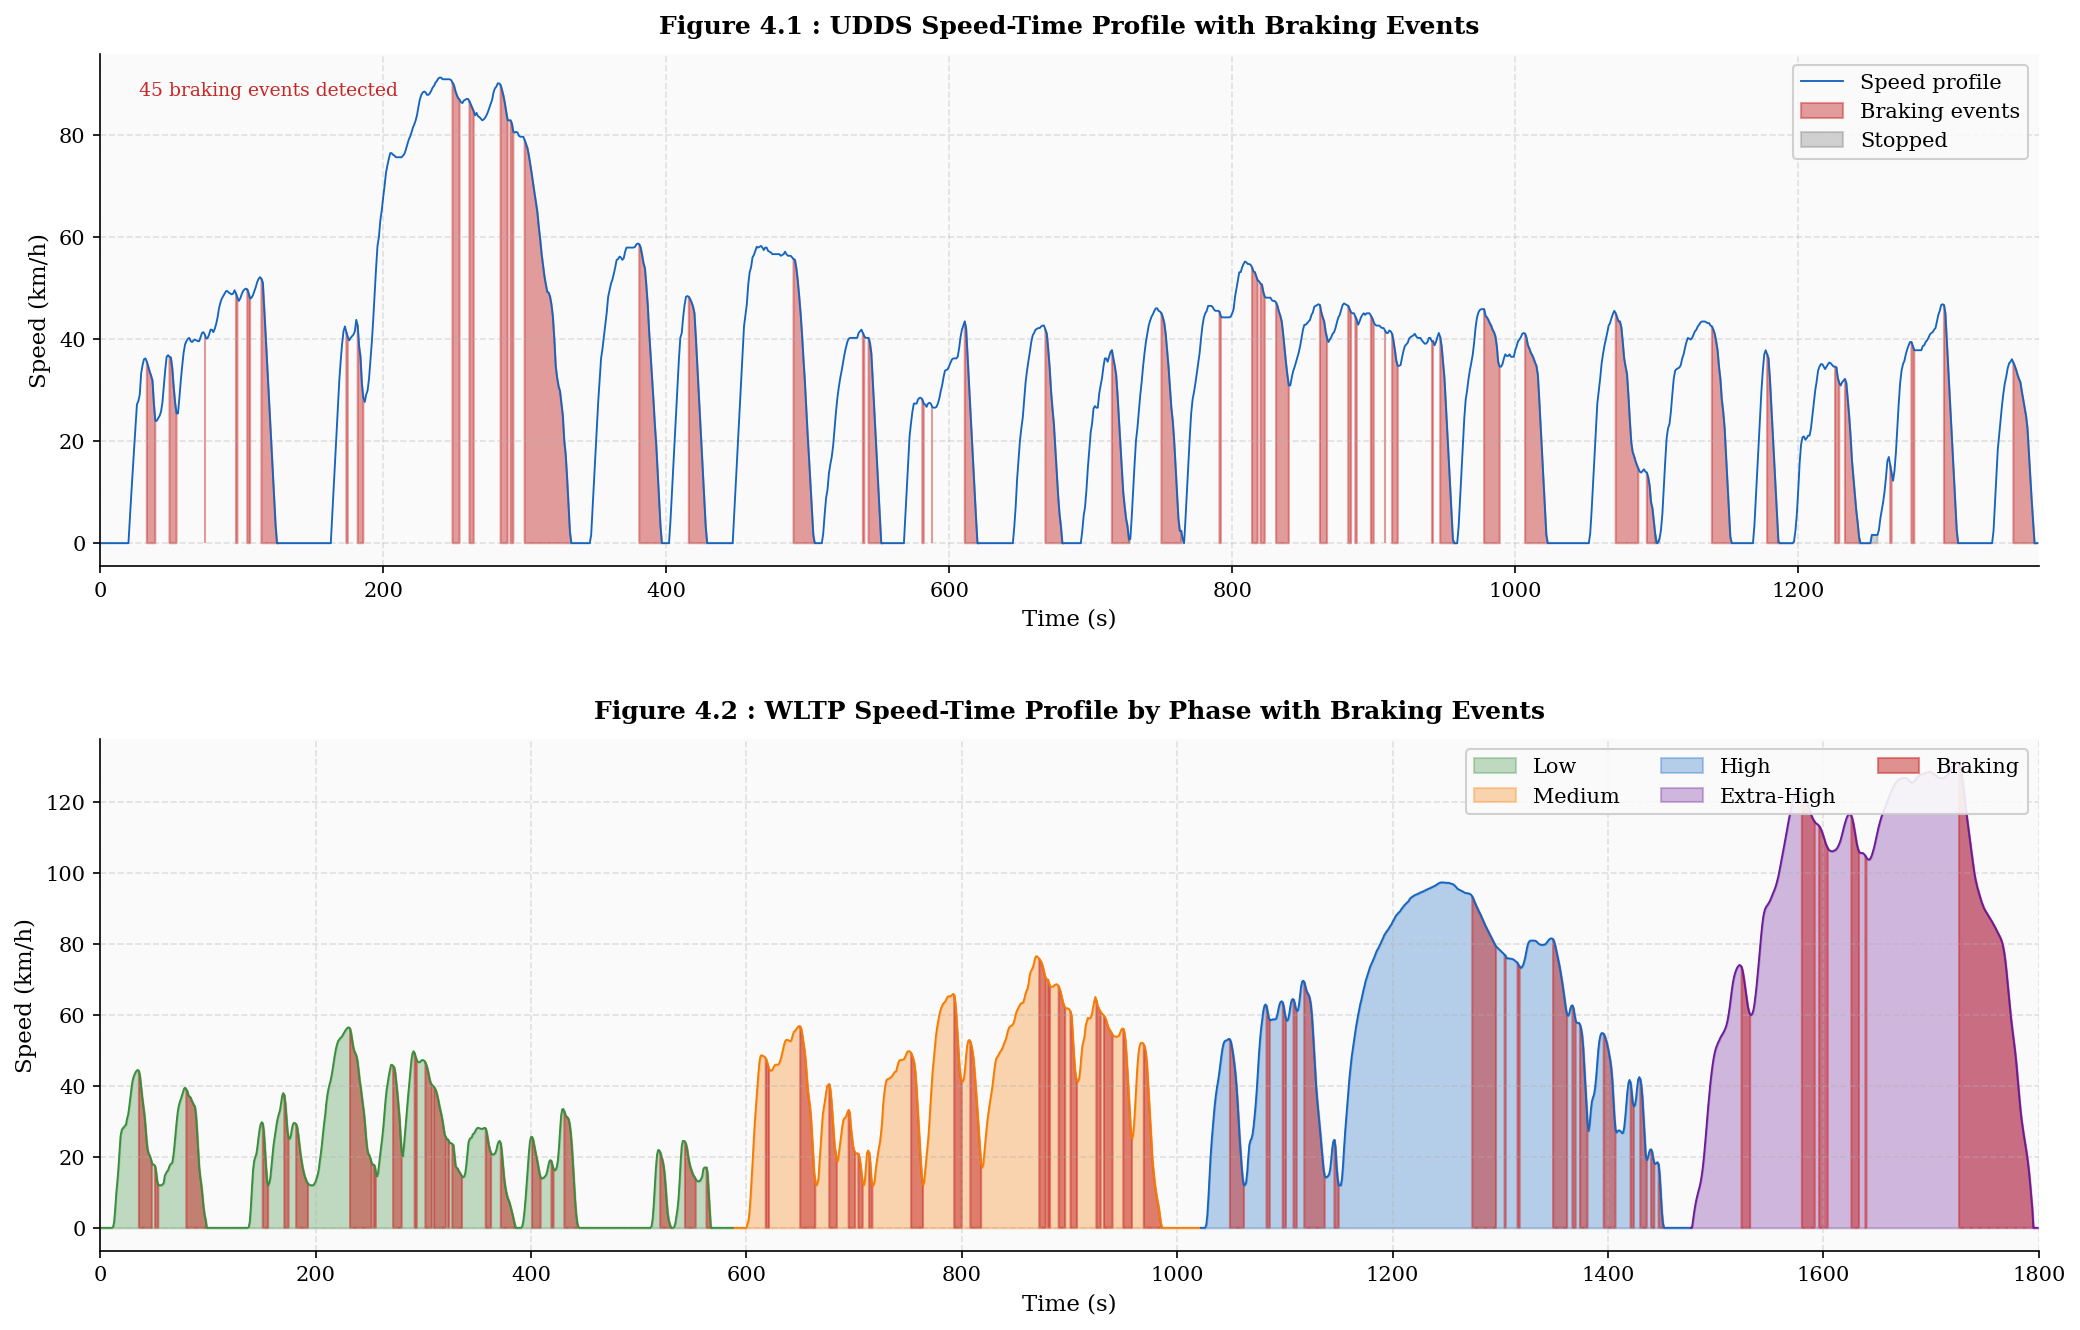

Figure 4.1 and 4.2 saved.


In [19]:
# Figure 4.1 and 4.2: Speed-Time Profiles
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

ax = axes[0]
ax.plot(udds['time_s'], udds['speed_kmh'], color='#1565C0', lw=0.9, label='Speed profile')
ax.fill_between(udds['time_s'], 0, udds['speed_kmh'],
                where=udds['is_braking'], alpha=0.45, color='#C62828', label='Braking events')
ax.fill_between(udds['time_s'], 0, udds['speed_kmh'],
                where=udds['is_stopped'], alpha=0.25, color='#555555', label='Stopped')
ax.set_title('Figure 4.1 : UDDS Speed-Time Profile with Braking Events', fontweight='bold', pad=10)
ax.set_ylabel('Speed (km/h)')
ax.set_xlabel('Time (s)')
ax.legend(loc='upper right', framealpha=0.9)
ax.set_xlim(0, 1370)
ax.annotate(f'{len(udds_events)} braking events detected', xy=(0.02,0.92),
            xycoords='axes fraction', fontsize=9, color='#C62828')

ax = axes[1]
phase_colors = {'Low':'#388E3C','Medium':'#F57C00','High':'#1565C0','Extra-High':'#6A1B9A'}
for phase, col in phase_colors.items():
    mask = wltp['phase'] == phase
    ax.fill_between(wltp['time_s'][mask], 0, wltp['speed_kmh'][mask],
                    alpha=0.3, color=col, label=phase)
    ax.plot(wltp['time_s'][mask], wltp['speed_kmh'][mask], color=col, lw=0.9)
ax.fill_between(wltp['time_s'], 0, wltp['speed_kmh'],
                where=wltp['is_braking'], alpha=0.5, color='#C62828', label='Braking')
ax.set_title('Figure 4.2 : WLTP Speed-Time Profile by Phase with Braking Events', fontweight='bold', pad=10)
ax.set_ylabel('Speed (km/h)')
ax.set_xlabel('Time (s)')
ax.legend(loc='upper right', framealpha=0.9, ncol=3)
ax.set_xlim(0, 1800)

plt.tight_layout(h_pad=3)
plt.savefig('outputs/figures/Figure4_1_2_Speed_Profiles.png', dpi=300)
plt.show()
print("Figure 4.1 and 4.2 saved.")


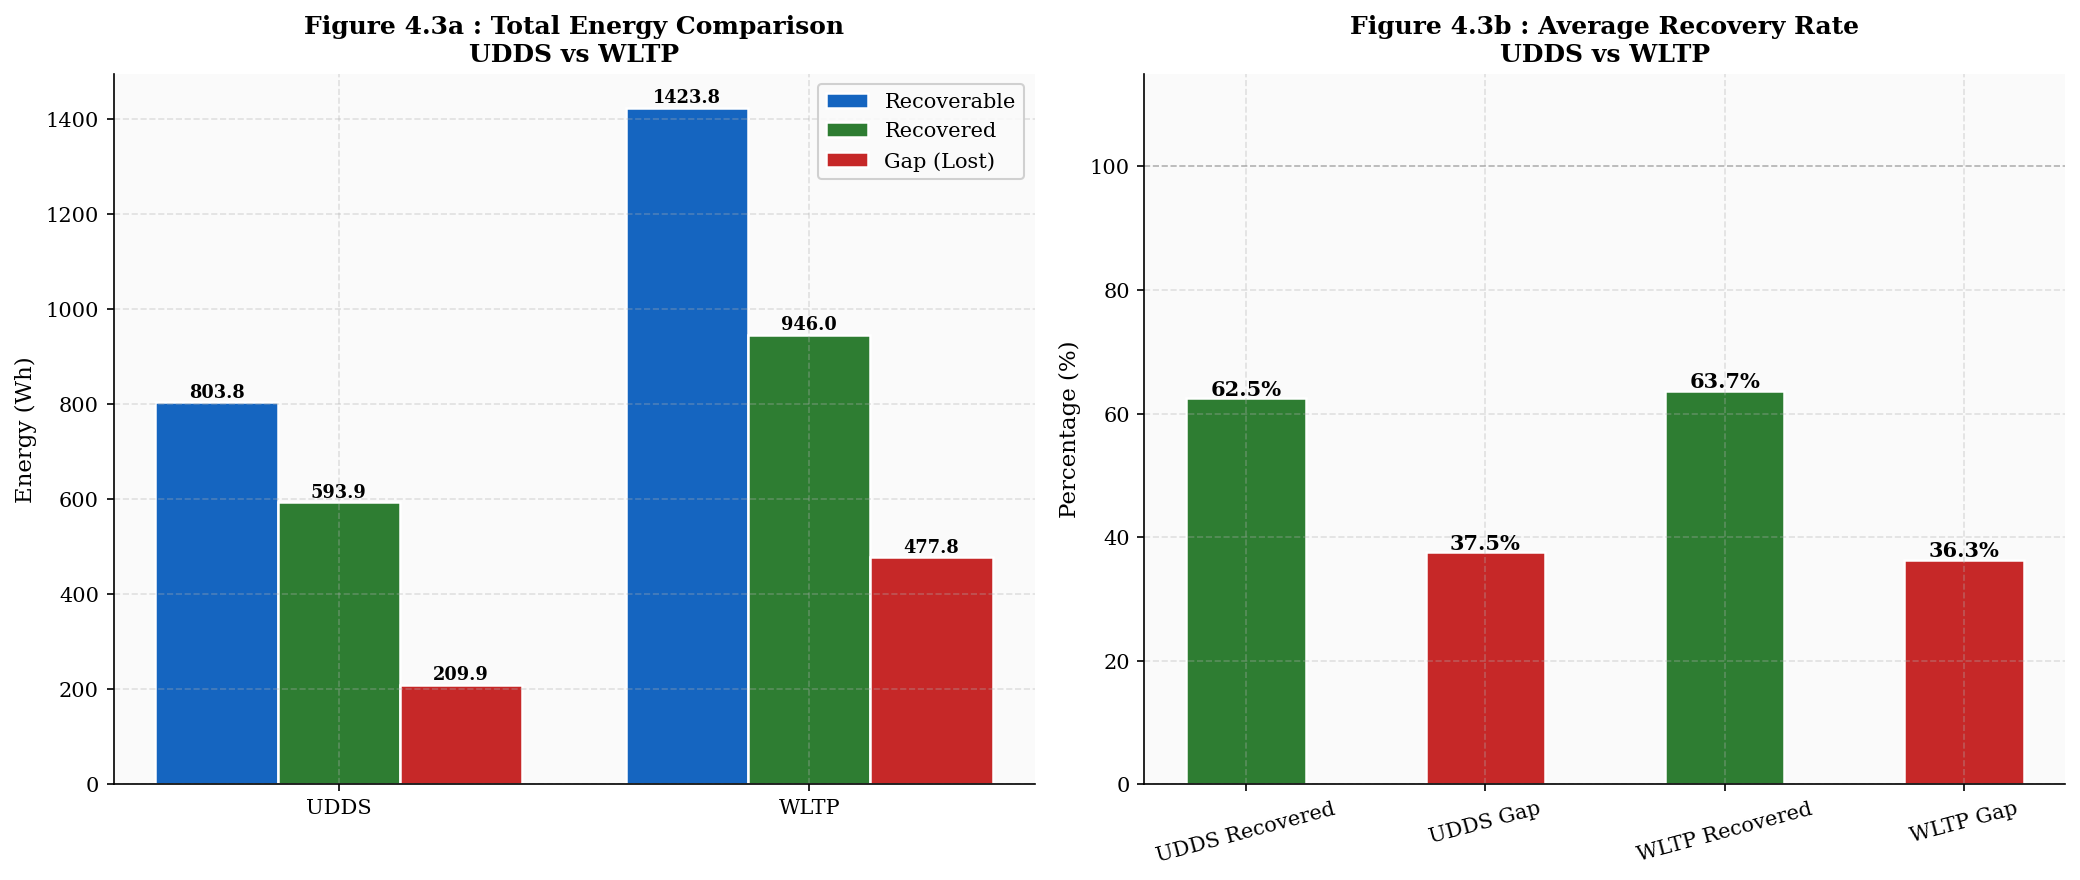

Figure 4.3 saved.


In [20]:
# Figure 4.3: Energy Comparison Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

rec_u = udds_results['e_recoverable_Wh'].sum()
rcv_u = udds_results['e_recovered_Wh'].sum()
gap_u = udds_results['e_gap_Wh'].sum()
rec_w = wltp_results['e_recoverable_Wh'].sum()
rcv_w = wltp_results['e_recovered_Wh'].sum()
gap_w = wltp_results['e_gap_Wh'].sum()

x = np.arange(2)
w = 0.26
bars1 = axes[0].bar(x-w, [rec_u, rec_w], w, color='#1565C0', label='Recoverable', edgecolor='white', lw=1.2)
bars2 = axes[0].bar(x,   [rcv_u, rcv_w], w, color='#2E7D32', label='Recovered',   edgecolor='white', lw=1.2)
bars3 = axes[0].bar(x+w, [gap_u, gap_w], w, color='#C62828', label='Gap (Lost)',   edgecolor='white', lw=1.2)

for group in [bars1, bars2, bars3]:
    for bar in group:
        h = bar.get_height()
        axes[0].text(bar.get_x()+bar.get_width()/2, h+2,
                     f'{h:.1f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

axes[0].set_title('Figure 4.3a : Total Energy Comparison\nUDDS vs WLTP', fontweight='bold')
axes[0].set_ylabel('Energy (Wh)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['UDDS', 'WLTP'])
axes[0].legend(framealpha=0.9)

# Recovery rate comparison
rate_u    = udds_results['recovery_rate_pct'].mean()
rate_w    = wltp_results['recovery_rate_pct'].mean()
gap_rate_u = 100 - rate_u
gap_rate_w = 100 - rate_w

bar_labels = ['UDDS Recovered', 'UDDS Gap', 'WLTP Recovered', 'WLTP Gap']
bar_vals   = [rate_u, gap_rate_u, rate_w, gap_rate_w]
bar_cols   = ['#2E7D32', '#C62828', '#2E7D32', '#C62828']

bars4 = axes[1].bar(bar_labels, bar_vals, color=bar_cols,
                    edgecolor='white', lw=1.2, width=0.5)
for bar in bars4:
    h = bar.get_height()
    axes[1].text(bar.get_x()+bar.get_width()/2, h+0.5,
                 f'{h:.1f}%', ha='center', fontsize=10, fontweight='bold')

axes[1].set_title('Figure 4.3b : Average Recovery Rate\nUDDS vs WLTP', fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_ylim(0, 115)
axes[1].axhline(100, color='black', ls='--', alpha=0.2, lw=0.8)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('outputs/figures/Figure4_3_Energy_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 4.3 saved.")

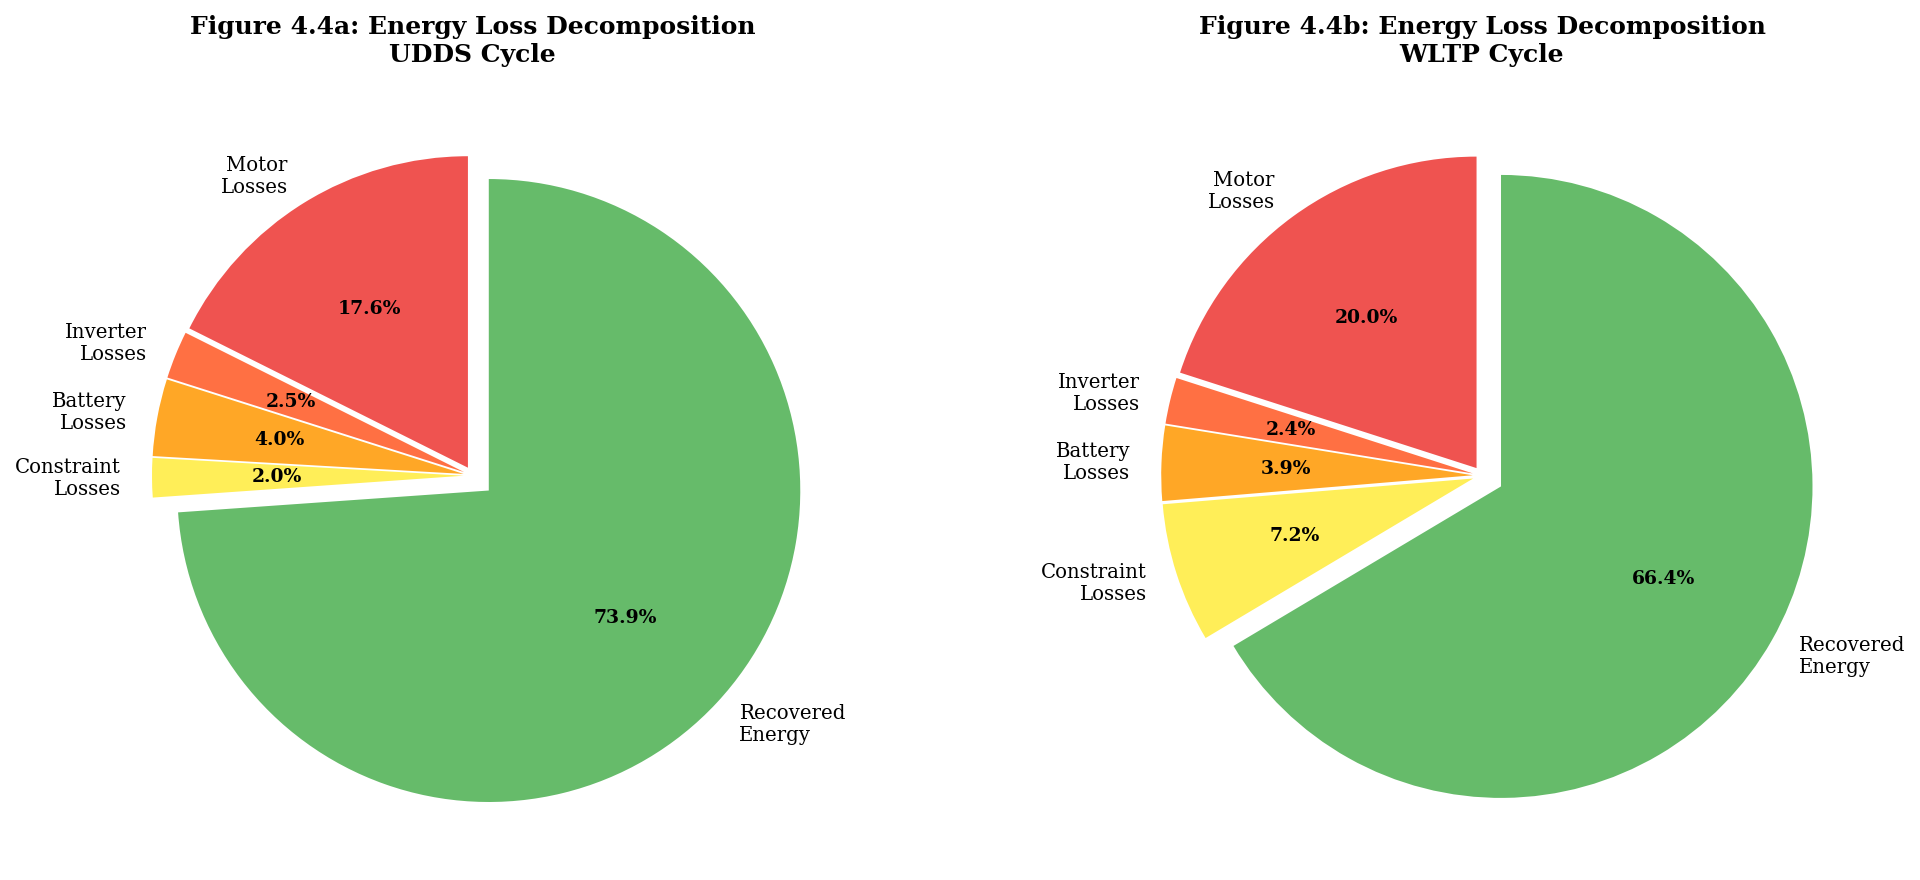

Figure 4.4 saved.


In [21]:
# Figure 4.4: Loss Decomposition Pie Charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
pie_labels  = ['Motor\nLosses','Inverter\nLosses','Battery\nLosses','Constraint\nLosses','Recovered\nEnergy']
pie_colors  = ['#EF5350','#FF7043','#FFA726','#FFEE58','#66BB6A']

for ax, (name, df) in zip(axes, [('UDDS', udds_results), ('WLTP', wltp_results)]):
    total  = df['e_recoverable_Wh'].sum()
    sizes  = [
        df['loss_motor_Wh'].sum(),
        df['loss_inverter_Wh'].sum(),
        df['loss_battery_Wh'].sum(),
        df['loss_constraints_Wh'].sum(),
        df['e_recovered_Wh'].sum()
    ]
    explode = [0.03]*5
    explode[-1] = 0.07
    wedges, texts, autotexts = ax.pie(
        sizes, labels=pie_labels, colors=pie_colors,
        autopct='%1.1f%%', explode=explode, startangle=90,
        textprops={'fontsize': 9.5}
    )
    for at in autotexts:
        at.set_fontweight('bold')
        at.set_fontsize(9)
    label = 'a' if name == 'UDDS' else 'b'
    ax.set_title(f'Figure 4.4{label}: Energy Loss Decomposition\n{name} Cycle', fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('outputs/figures/Figure4_4_Loss_Decomposition.png', dpi=300)
plt.show()
print("Figure 4.4 saved.")


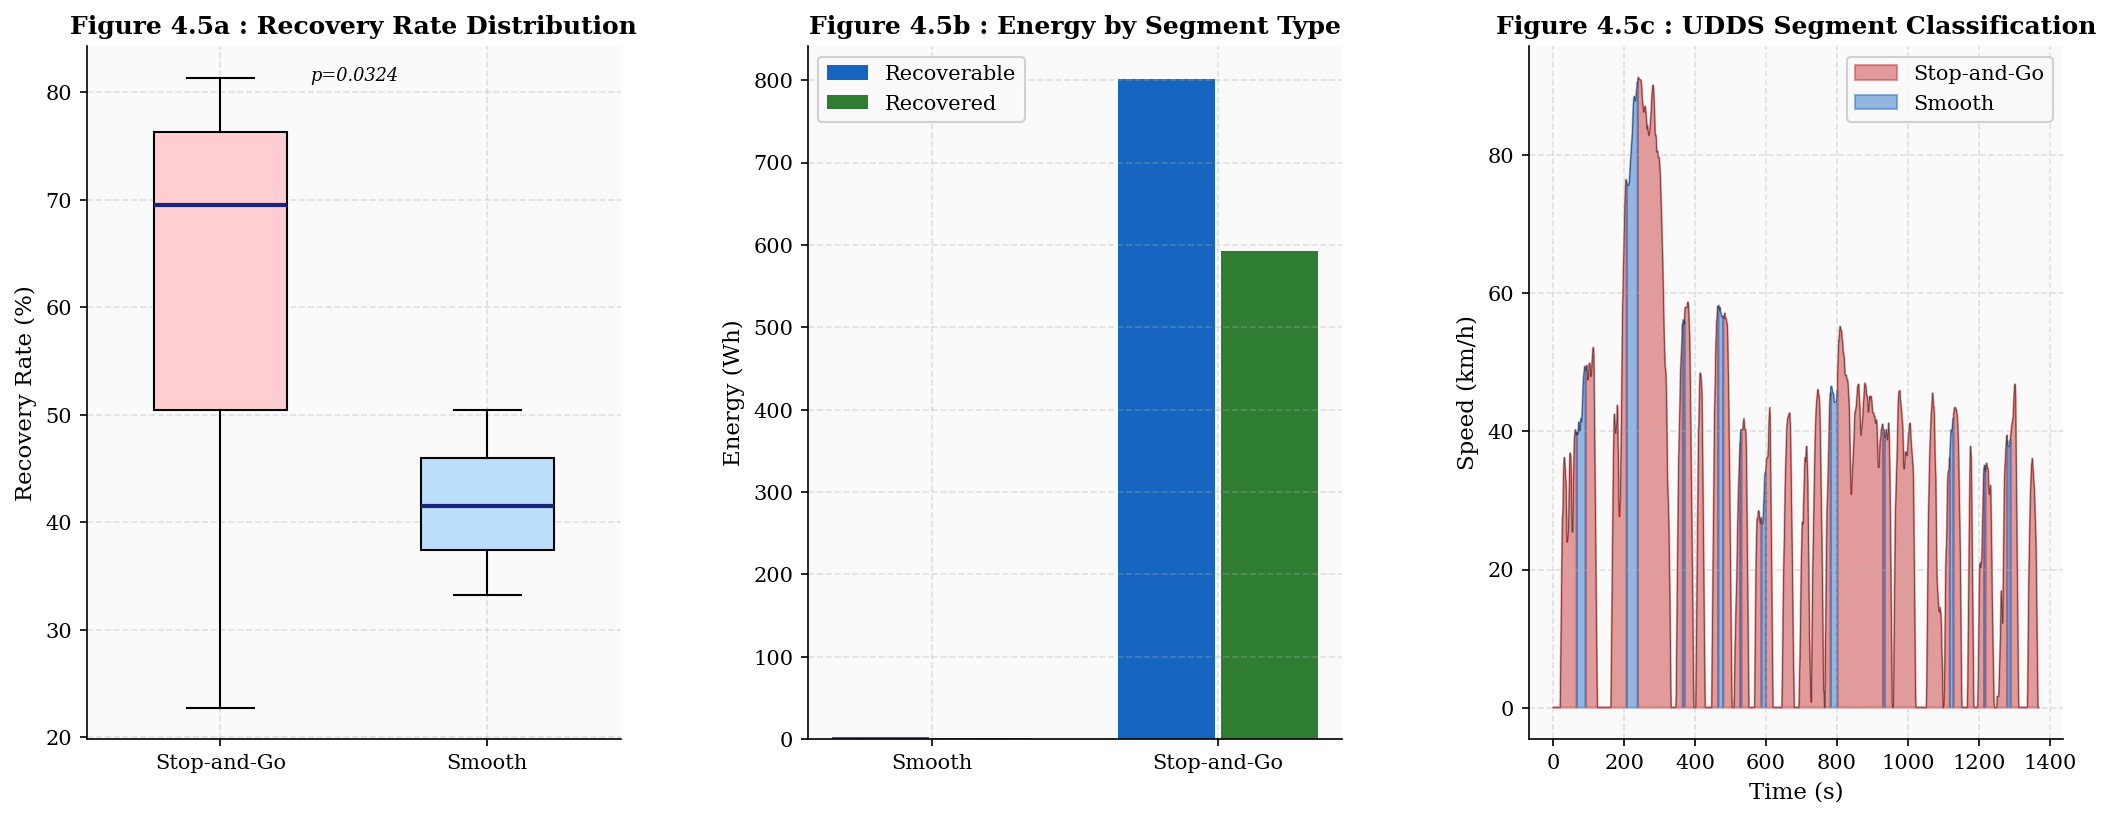

Figure 4.5 saved.


In [22]:
# Figure 4.5: Segment Analysis
fig = plt.figure(figsize=(17, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# Boxplot
ax0 = fig.add_subplot(gs[0])
sag_data = udds_results[udds_results['segment']=='Stop-and-Go']['recovery_rate_pct'].values
smo_data = udds_results[udds_results['segment']=='Smooth']['recovery_rate_pct'].values
bp = ax0.boxplot([sag_data, smo_data],
                 labels=['Stop-and-Go','Smooth'],
                 patch_artist=True, notch=False, widths=0.5)
for patch, col in zip(bp['boxes'], ['#FFCDD2','#BBDEFB']):
    patch.set_facecolor(col)
for med in bp['medians']:
    med.set_color('#1A237E')
    med.set_linewidth(2)
ax0.set_title('Figure 4.5a : Recovery Rate Distribution', fontweight='bold')
ax0.set_ylabel('Recovery Rate (%)')
if len(sag_data)>0 and len(smo_data)>0:
    ax0.text(0.5, 0.97, f'p={p_seg:.4f}', transform=ax0.transAxes,
             ha='center', va='top', fontsize=8.5, style='italic')

# Energy bar
ax1 = fig.add_subplot(gs[1])
segs_list = seg['segment'].tolist()
x2 = np.arange(len(segs_list))
ax1.bar(x2-0.18, seg['total_recoverable_Wh'], 0.34, color='#1565C0', label='Recoverable')
ax1.bar(x2+0.18, seg['total_recovered_Wh'],   0.34, color='#2E7D32', label='Recovered')
ax1.set_xticks(x2)
ax1.set_xticklabels(segs_list)
ax1.set_title('Figure 4.5b : Energy by Segment Type', fontweight='bold')
ax1.set_ylabel('Energy (Wh)')
ax1.legend(framealpha=0.9)

# Speed profile coloured
ax2 = fig.add_subplot(gs[2])
sc = {'Stop-and-Go':'#C62828','Smooth':'#1565C0'}
for seg_type, col in sc.items():
    mask = udds['segment'] == seg_type
    ax2.fill_between(udds['time_s'], 0, udds['speed_kmh'], where=mask, alpha=0.45, color=col, label=seg_type)
ax2.plot(udds['time_s'], udds['speed_kmh'], color='black', lw=0.4, alpha=0.5)
ax2.set_title('Figure 4.5c : UDDS Segment Classification', fontweight='bold')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Speed (km/h)')
ax2.legend(framealpha=0.9)

plt.savefig('outputs/figures/Figure4_5_Segment_Analysis.png', dpi=300)
plt.show()
print("Figure 4.5 saved.")


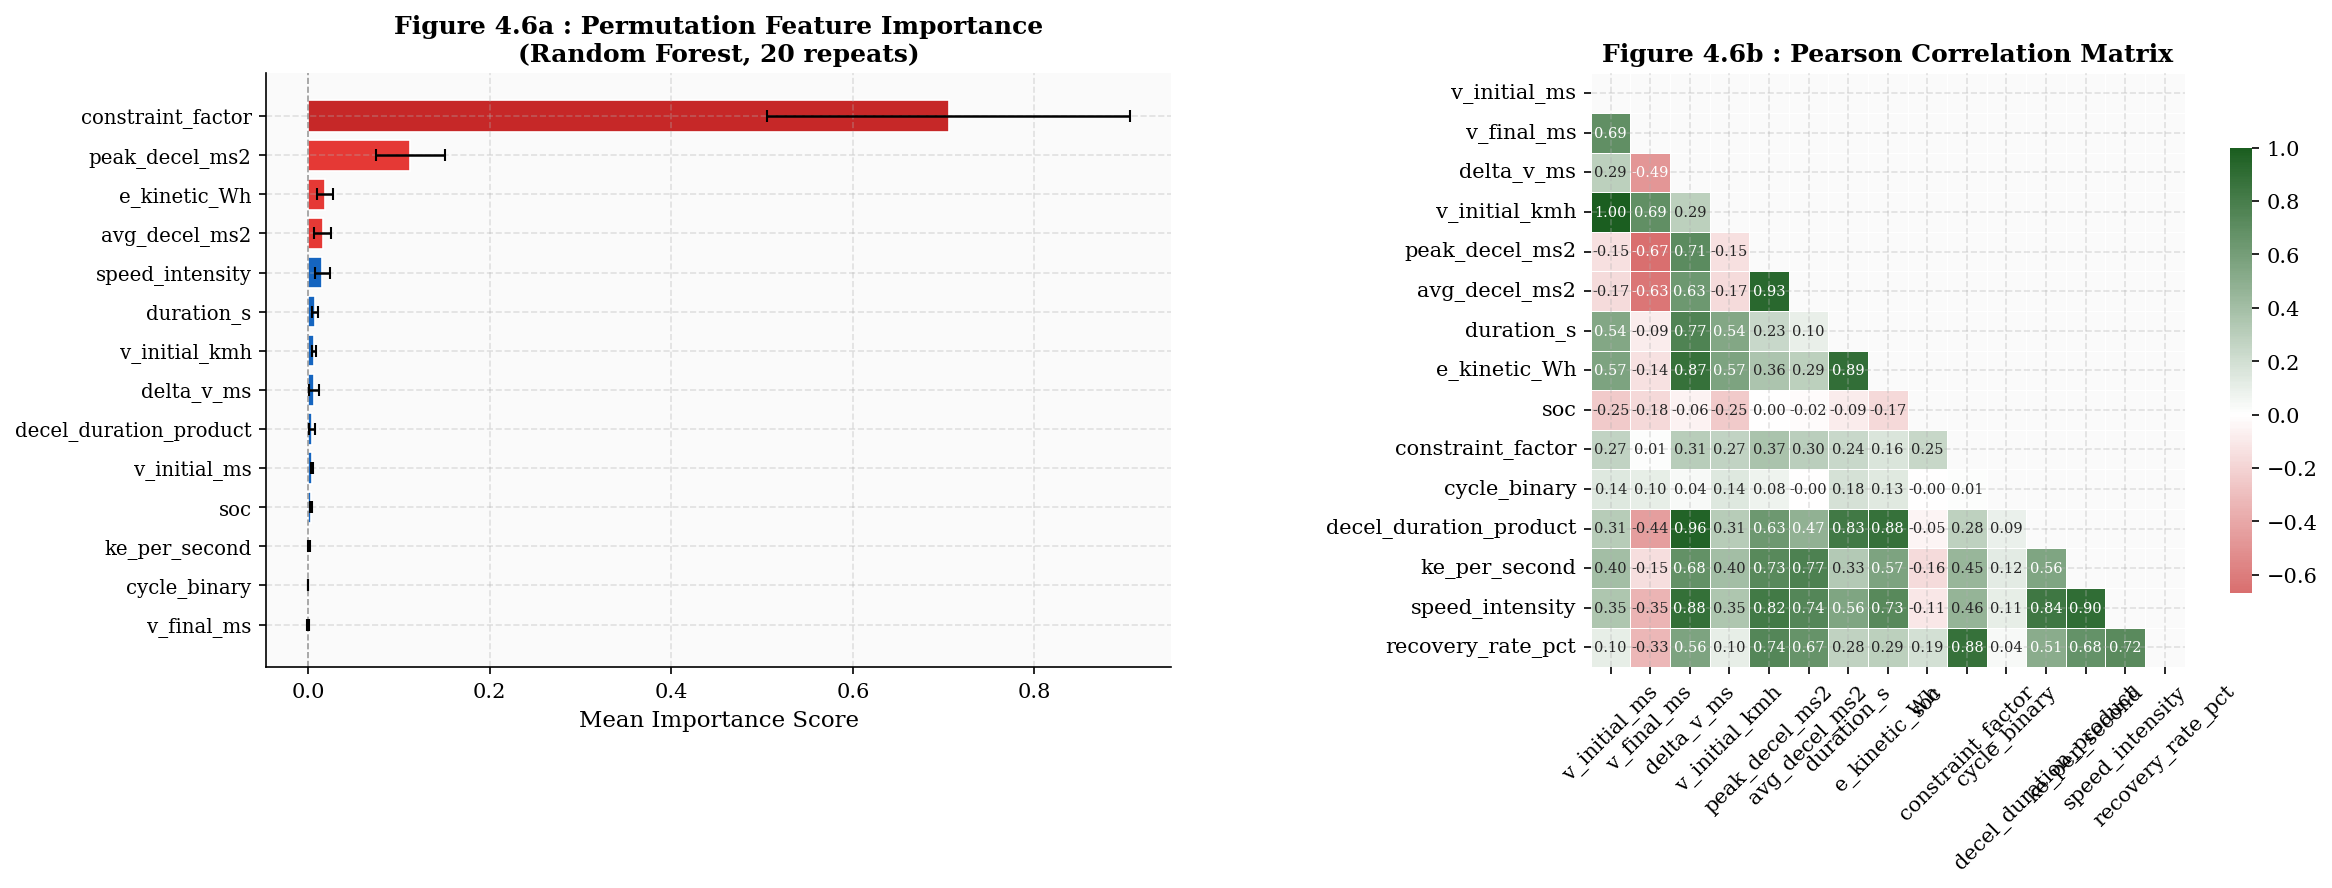

Figure 4.6 saved.


In [23]:
# Figure 4.6: Feature Importance (Paper 2 core figure)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Permutation importance with error bars
imp_sorted = imp_perm.sort_values(ascending=True)
std_sorted = imp_perm_std[imp_sorted.index]
cols_imp   = ['#C62828' if v == imp_sorted.max() else
              '#E53935' if v >= imp_sorted.quantile(0.75) else
              '#1565C0' for v in imp_sorted]

axes[0].barh(range(len(imp_sorted)), imp_sorted.values,
             xerr=std_sorted.values, color=cols_imp,
             edgecolor='white', lw=0.8, capsize=3, error_kw={'elinewidth':1.2})
axes[0].set_yticks(range(len(imp_sorted)))
axes[0].set_yticklabels(imp_sorted.index, fontsize=9.5)
axes[0].set_title('Figure 4.6a : Permutation Feature Importance\n(Random Forest, 20 repeats)', fontweight='bold')
axes[0].set_xlabel('Mean Importance Score')
axes[0].axvline(0, color='black', lw=0.8, ls='--', alpha=0.3)

# Correlation heatmap
corr_data = pd.concat([X, pd.Series(y, name='recovery_rate_pct', index=X.index)], axis=1).corr()
mask = np.triu(np.ones_like(corr_data, dtype=bool))
cmap = LinearSegmentedColormap.from_list('rg', ['#C62828','#FFFFFF','#1B5E20'])
sns.heatmap(corr_data, mask=mask, ax=axes[1], cmap=cmap, center=0,
            annot=True, fmt='.2f', square=True, linewidths=0.4,
            cbar_kws={'shrink':0.75}, annot_kws={'size':7})
axes[1].set_title('Figure 4.6b : Pearson Correlation Matrix', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('outputs/figures/Figure4_6_Feature_Importance.png', dpi=300)
plt.show()
print("Figure 4.6 saved.")


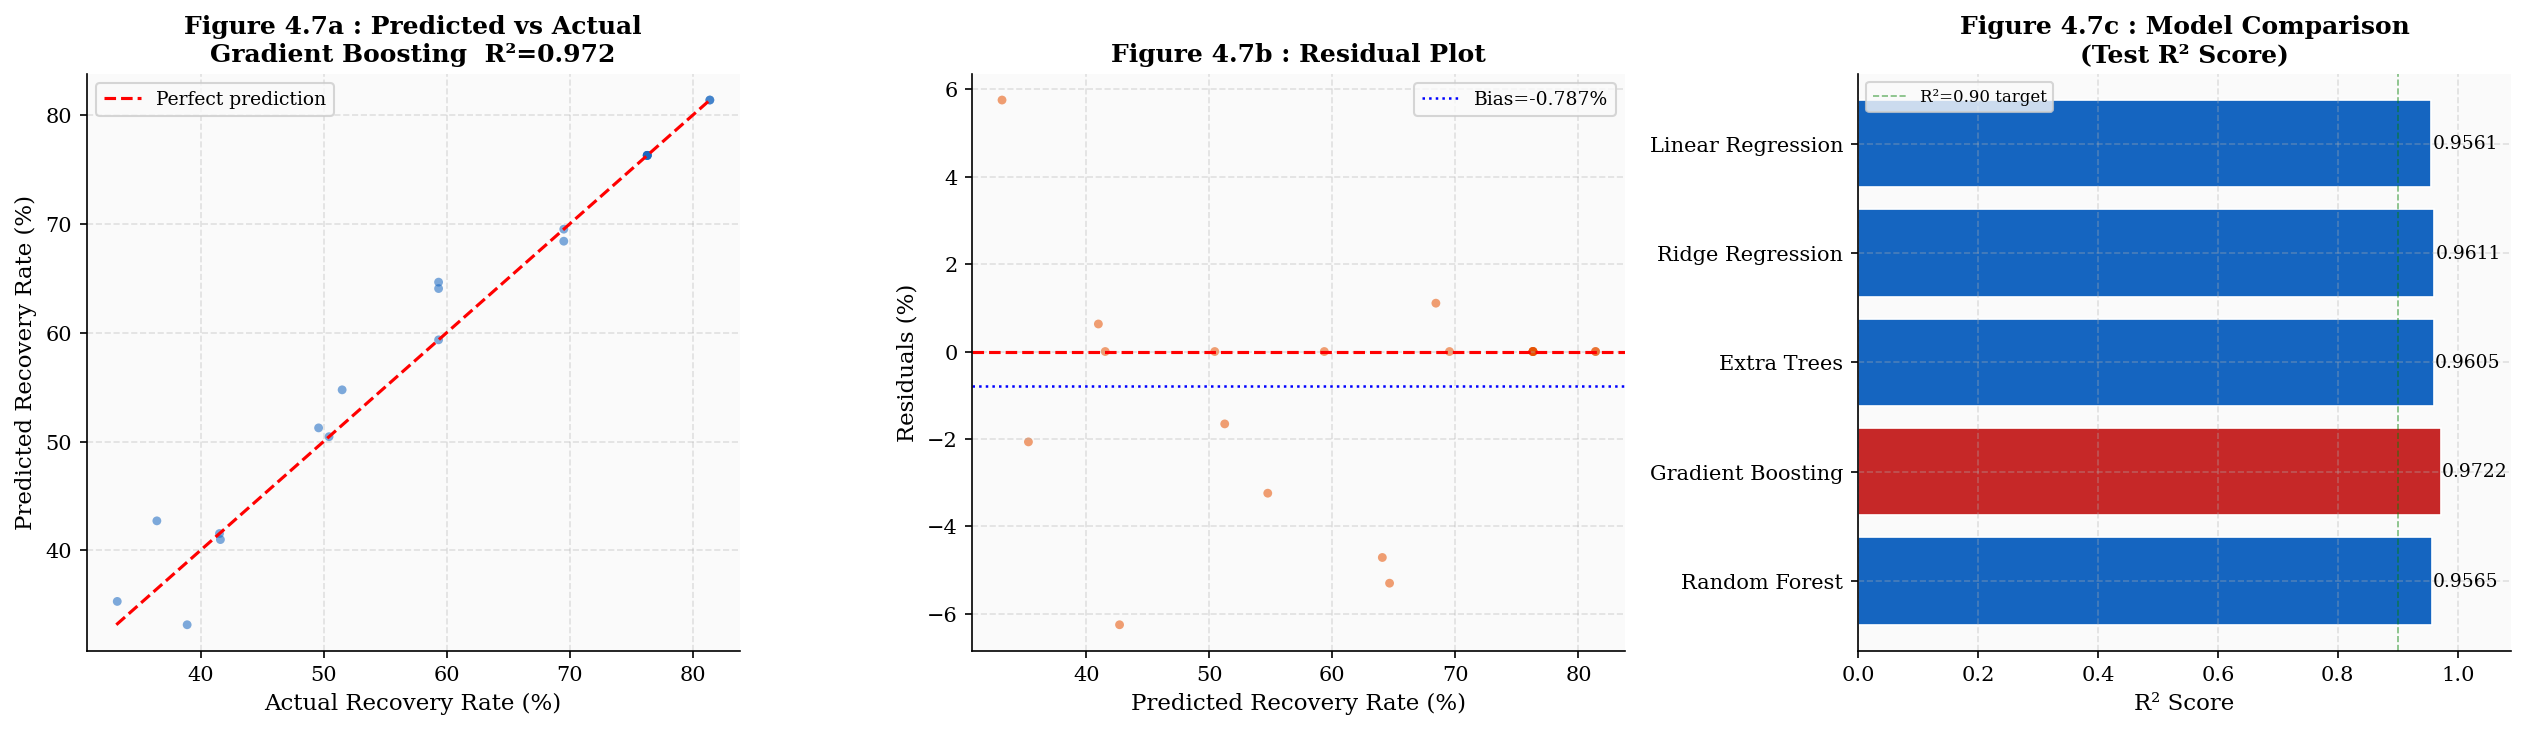

Figure 4.7 saved.


In [24]:
# Figure 4.7: Model Performance (Paper 2)
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

y_pred_best = ml_results[best_name]['y_pred']
residuals   = y_test - y_pred_best

# Predicted vs actual
mn = min(y_test.min(), y_pred_best.min())
mx = max(y_test.max(), y_pred_best.max())
axes[0].scatter(y_test, y_pred_best, alpha=0.55, color='#1565C0', s=18, edgecolors='none')
axes[0].plot([mn,mx],[mn,mx],'r--',lw=1.5,label='Perfect prediction')
axes[0].set_title(f'Figure 4.7a : Predicted vs Actual\n{best_name}  R²={ml_results[best_name]["r2"]:.3f}', fontweight='bold')
axes[0].set_xlabel('Actual Recovery Rate (%)')
axes[0].set_ylabel('Predicted Recovery Rate (%)')
axes[0].legend(fontsize=9)

# Residuals
axes[1].scatter(y_pred_best, residuals, alpha=0.55, color='#E65100', s=18, edgecolors='none')
axes[1].axhline(0, color='red', ls='--', lw=1.5)
axes[1].axhline(residuals.mean(), color='blue', lw=1.2, ls=':', label=f'Bias={residuals.mean():.3f}%')
axes[1].set_title('Figure 4.7b : Residual Plot', fontweight='bold')
axes[1].set_xlabel('Predicted Recovery Rate (%)')
axes[1].set_ylabel('Residuals (%)')
axes[1].legend(fontsize=9)

# Model comparison R2
model_names = list(ml_results.keys())
r2_vals     = [ml_results[m]['r2'] for m in model_names]
bar_cols     = ['#C62828' if m==best_name else '#1565C0' for m in model_names]
axes[2].barh(model_names, r2_vals, color=bar_cols, edgecolor='white', lw=0.8)
for i,(name,val) in enumerate(zip(model_names,r2_vals)):
    axes[2].text(val+0.002, i, f'{val:.4f}', va='center', fontsize=9)
axes[2].set_title('Figure 4.7c : Model Comparison\n(Test R² Score)', fontweight='bold')
axes[2].set_xlabel('R² Score')
axes[2].set_xlim(0, max(r2_vals)*1.12)
axes[2].axvline(0.90, color='green', ls='--', lw=0.8, alpha=0.5, label='R²=0.90 target')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('outputs/figures/Figure4_7_Model_Performance.png', dpi=300)
plt.show()
print("Figure 4.7 saved.")


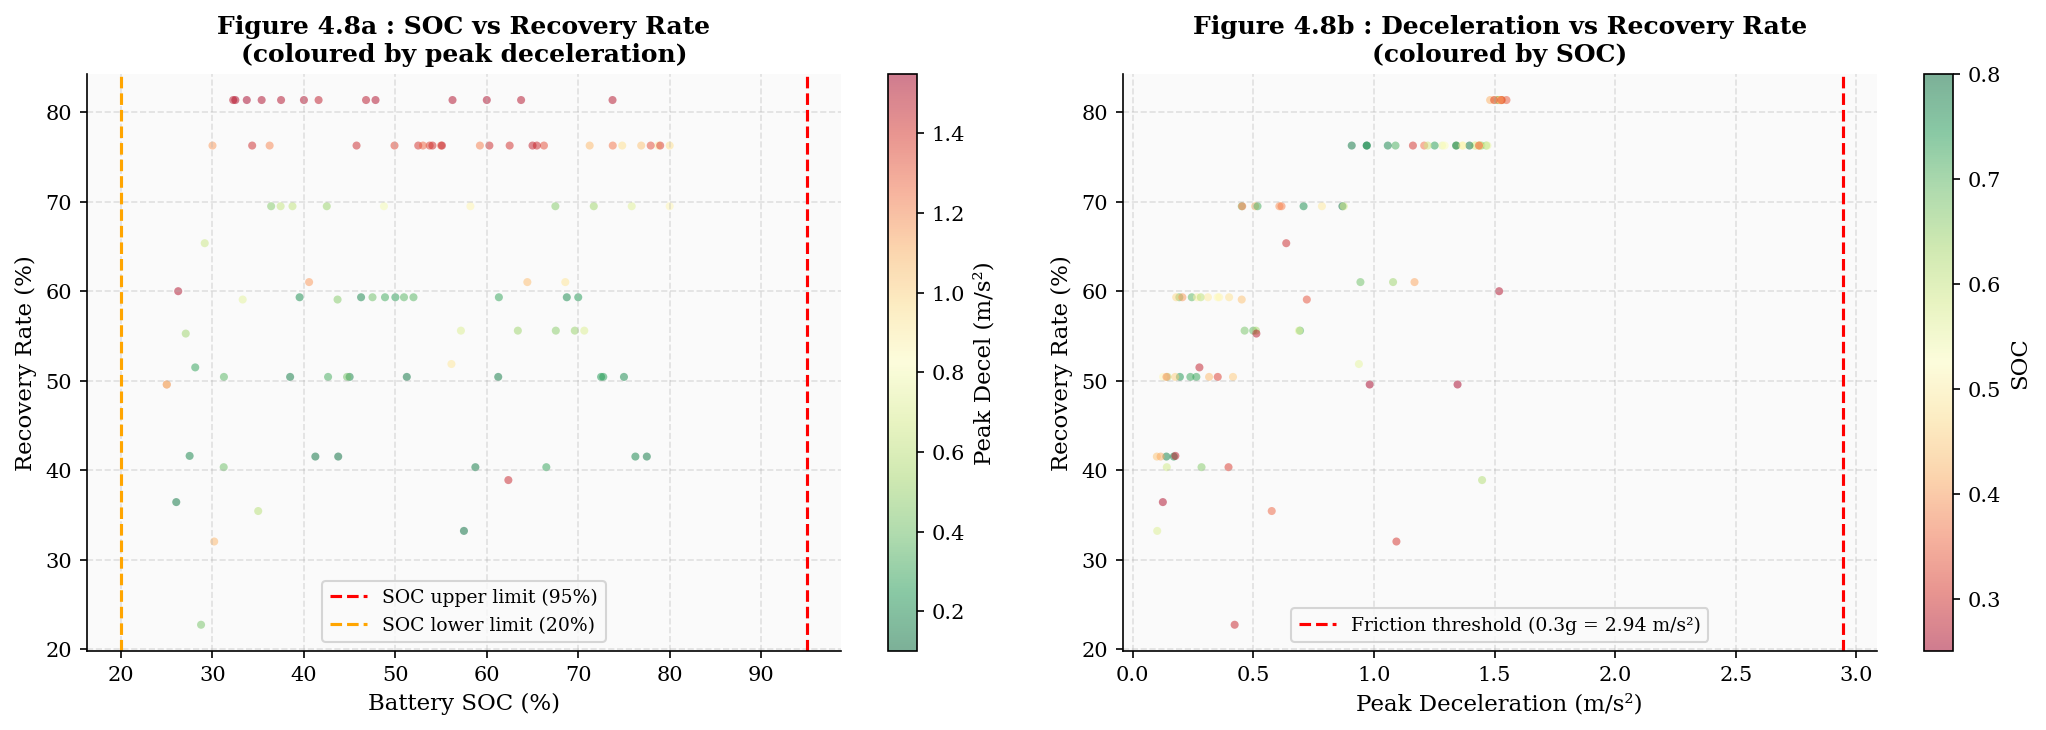

Figure 4.8 saved.


In [25]:
# Figure 4.8: SOC effect on recovery rate
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SOC vs recovery rate scatter
sc = axes[0].scatter(all_results['soc']*100, all_results['recovery_rate_pct'],
                     c=all_results['peak_decel_ms2'], cmap='RdYlGn_r',
                     alpha=0.5, s=15, edgecolors='none')
plt.colorbar(sc, ax=axes[0], label='Peak Decel (m/s²)')
axes[0].axvline(VP['soc_upper']*100, color='red', ls='--', lw=1.5, label=f'SOC upper limit ({VP["soc_upper"]*100:.0f}%)')
axes[0].axvline(VP['soc_lower']*100, color='orange', ls='--', lw=1.5, label=f'SOC lower limit ({VP["soc_lower"]*100:.0f}%)')
axes[0].set_xlabel('Battery SOC (%)')
axes[0].set_ylabel('Recovery Rate (%)')
axes[0].set_title('Figure 4.8a : SOC vs Recovery Rate\n(coloured by peak deceleration)', fontweight='bold')
axes[0].legend(fontsize=9)

# Deceleration vs recovery rate
sc2 = axes[1].scatter(all_results['peak_decel_ms2'], all_results['recovery_rate_pct'],
                      c=all_results['soc'], cmap='RdYlGn',
                      alpha=0.5, s=15, edgecolors='none')
plt.colorbar(sc2, ax=axes[1], label='SOC')
axes[1].axvline(VP['friction_threshold_ms2'], color='red', ls='--', lw=1.5,
                label=f'Friction threshold ({VP["friction_threshold_g"]}g = {VP["friction_threshold_ms2"]:.2f} m/s²)')
axes[1].set_xlabel('Peak Deceleration (m/s²)')
axes[1].set_ylabel('Recovery Rate (%)')
axes[1].set_title('Figure 4.8b : Deceleration vs Recovery Rate\n(coloured by SOC)', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('outputs/figures/Figure4_8_SOC_Decel_Analysis.png', dpi=300)
plt.show()
print("Figure 4.8 saved.")


## Section 16: Exporting the Results

Everything is written to a single Excel workbook so the raw per-event data sits alongside the dissertation rather than being trapped inside the notebook.

The workbook has separate sheets for the UDDS events, the WLTP events, the segment analysis, the feature matrix used for the machine learning, and the loss breakdown. Anyone who wants to check a number in Chapter 4 can trace it back to the individual braking event it came from.


In [26]:
with pd.ExcelWriter('outputs/data/Dissertation_Results_st20341331.xlsx', engine='openpyxl') as writer:
    udds_results.to_excel(writer, sheet_name='UDDS_All_Events',    index=False)
    wltp_results.to_excel(writer, sheet_name='WLTP_All_Events',    index=False)
    seg.to_excel(writer,          sheet_name='Segment_Analysis',   index=False)
    X.assign(recovery_rate_pct=y).to_excel(writer, sheet_name='ML_Features', index=False)
    loss_df.to_excel(writer,      sheet_name='Loss_Breakdown',     index=False)
    pd.DataFrame([{
        'Metric': k,
        'UDDS':   v,
        'WLTP':   ml_results[k]['r2'] if k in ml_results else ''
    } for k,v in {m: ml_results[m]['r2'] for m in ml_results}.items()]).to_excel(
        writer, sheet_name='ML_Model_Comparison', index=False)

print("All results exported to: outputs/data/Dissertation_Results_st20341331.xlsx")
print()
print("Figures saved to: outputs/figures/")
import glob
for f in sorted(glob.glob('outputs/figures/*.png')):
    print(f"  {f}")


All results exported to: outputs/data/Dissertation_Results_st20341331.xlsx

Figures saved to: outputs/figures/
  outputs/figures/Figure4_1_2_Speed_Profiles.png
  outputs/figures/Figure4_3_Energy_Comparison.png
  outputs/figures/Figure4_4_Loss_Decomposition.png
  outputs/figures/Figure4_5_Segment_Analysis.png
  outputs/figures/Figure4_6_Feature_Importance.png
  outputs/figures/Figure4_7_Model_Performance.png
  outputs/figures/Figure4_8_SOC_Decel_Analysis.png


## Section 17: Table 4 for the Dissertation

This builds the summary table that appears as Table 4 in Chapter 4, pulling together event counts, energy totals, recovery rates, loss shares, segment results, and machine learning metrics for both cycles side by side.

I generate it here rather than typing it into Word by hand, so there is no chance of a number being transcribed wrongly between the analysis and the dissertation.


In [27]:
sag = udds_results[udds_results['segment']=='Stop-and-Go']
smo = udds_results[udds_results['segment']=='Smooth']

summary = pd.DataFrame({
    'Metric': [
        'Total braking events detected',
        'Total recoverable energy (Wh)',
        'Total recovered energy (Wh)',
        'Total energy gap (Wh)',
        'Average recovery rate (%)',
        'Median recovery rate (%)',
        'Standard deviation (%)',
        'Average energy gap (%)',
        'Stop-and-Go avg recovery rate (%)',
        'Smooth driving avg recovery rate (%) ',
        'Segment difference significant?',
        'Motor loss share (% of recoverable)',
        'Inverter loss share (%)',
        'Battery loss share (%)',
        'Constraint loss share (%)',
        'Best ML model',
        'Best ML R2 (test)',
        'Best ML RMSE (%)',
        'Best ML MAE (%)',
        'Cross-validation R2 (5-fold)',
    ],
    'UDDS': [
        len(udds_results),
        f"{udds_results.e_recoverable_Wh.sum():.3f}",
        f"{udds_results.e_recovered_Wh.sum():.3f}",
        f"{udds_results.e_gap_Wh.sum():.3f}",
        f"{udds_results.recovery_rate_pct.mean():.2f}",
        f"{udds_results.recovery_rate_pct.median():.2f}",
        f"{udds_results.recovery_rate_pct.std():.2f}",
        f"{udds_results.gap_pct.mean():.2f}",
        f"{sag.recovery_rate_pct.mean():.2f}" if len(sag)>0 else "N/A",
        f"{smo.recovery_rate_pct.mean():.2f}" if len(smo)>0 else "N/A",
        f"p={p_seg:.4f} (Yes)" if p_seg<0.05 else f"p={p_seg:.4f} (No)",
        f"{udds_loss['motor_pct']:.2f}",
        f"{udds_loss['inverter_pct']:.2f}",
        f"{udds_loss['battery_pct']:.2f}",
        f"{udds_loss['constraint_pct']:.2f}",
        best_name,
        f"{ml_results[best_name]['r2']:.4f}",
        f"{ml_results[best_name]['rmse']:.4f}",
        f"{ml_results[best_name]['mae']:.4f}",
        f"{ml_results[best_name]['cv_mean']:.4f} +/- {ml_results[best_name]['cv_std']:.4f}",
    ],
    'WLTP': [
        len(wltp_results),
        f"{wltp_results.e_recoverable_Wh.sum():.3f}",
        f"{wltp_results.e_recovered_Wh.sum():.3f}",
        f"{wltp_results.e_gap_Wh.sum():.3f}",
        f"{wltp_results.recovery_rate_pct.mean():.2f}",
        f"{wltp_results.recovery_rate_pct.median():.2f}",
        f"{wltp_results.recovery_rate_pct.std():.2f}",
        f"{wltp_results.gap_pct.mean():.2f}",
        'N/A (full cycle)',
        'N/A (full cycle)',
        'N/A (full cycle)',
        f"{wltp_loss['motor_pct']:.2f}",
        f"{wltp_loss['inverter_pct']:.2f}",
        f"{wltp_loss['battery_pct']:.2f}",
        f"{wltp_loss['constraint_pct']:.2f}",
        best_name,
        f"{ml_results[best_name]['r2']:.4f}",
        f"{ml_results[best_name]['rmse']:.4f}",
        f"{ml_results[best_name]['mae']:.4f}",
        f"{ml_results[best_name]['cv_mean']:.4f} +/- {ml_results[best_name]['cv_std']:.4f}",
    ]
})

pd.set_option('display.max_colwidth', 60)
print("Table 4.4: Summary of Key Findings")
print("="*85)
print(summary.to_string(index=False))
print()



Table 4.4: Summary of Key Findings
                               Metric              UDDS              WLTP
        Total braking events detected                45                54
        Total recoverable energy (Wh)           803.804          1423.806
          Total recovered energy (Wh)           593.864           946.013
                Total energy gap (Wh)           209.939           477.793
            Average recovery rate (%)             62.45             63.68
             Median recovery rate (%)             69.52             61.04
               Standard deviation (%)             16.48             13.26
               Average energy gap (%)             37.55             36.32
    Stop-and-Go avg recovery rate (%)             63.93  N/A (full cycle)
Smooth driving avg recovery rate (%)              41.74  N/A (full cycle)
      Segment difference significant?    p=0.0324 (Yes)  N/A (full cycle)
  Motor loss share (% of recoverable)             17.62             20.04
   

## References

Every parameter value and modelling decision in this notebook is traceable to one of the sources below. They are the same references used in the dissertation, listed here so the notebook stands on its own.

### Datasets and standards

United States Environmental Protection Agency (2023) *Dynamometer drive schedules*. Available at: https://www.epa.gov/vehicle-and-fuel-emissions-testing/dynamometer-drive-schedules (Accessed: 15 June 2026). — Source of the UDDS speed trace.

United Nations Economic Commission for Europe (2021) *UN Regulation No. 154: Worldwide harmonised light vehicles test procedure (WLTP)*. Available at: https://unece.org/transport/vehicle-regulations (Accessed: 20 June 2026). — Defines the WLTP Class 3b cycle and its four phases.

European Commission Joint Research Centre (2025) *wltp Python package*. Available at: https://pypi.org/project/wltp/ (Accessed: 20 June 2026). — Used to load the official Class 3b trace in Section 3.

### Vehicle parameters

Ehsani, M., Gao, Y., Longo, S. and Ebrahimi, K.M. (2018) *Modern Electric, Hybrid Electric, and Fuel Cell Vehicles*. 3rd edn. Boca Raton: CRC Press. — Vehicle mass, drag and rolling resistance.

Szumska, E.M. (2025) 'Regenerative braking systems in electric vehicles: a comprehensive review', *Energies*, 18(10), p. 2067. — Peak motor efficiency of 0.92.

He, Q., Yang, Y., Luo, C., Zhai, J., Luo, R. and Fu, C. (2022) 'Energy recovery strategy optimization of dual-motor drive electric vehicle based on braking safety and efficient recovery', *Energy*, 248, p. 123543. — Inverter efficiency, the 0.3g friction threshold, and the motor operating point argument behind the tiered efficiency model in Section 6.

Chidambaram, S., Muthukrishnan, M. and Ramachandran, M. (2023) 'Effect of regenerative braking on battery life and performance in electric vehicles', *Journal of Energy Storage*, 72, p. 108456. — Battery charging efficiency of 0.95.

Zu, E.H., Wang, J., Huang, Z. and Zhang, J. (2024) 'Energy recovery decision of electric vehicles based on improved fuzzy control', *Processes*, 12, p. 2919. — The 95% SOC cut-off and the linear SOC profile used in Section 6.

Sandrini, C., Chindamo, D. and Gadola, M. (2022) 'Regenerative braking logic that maximizes energy recovery ensuring the vehicle stability', *Energies*, 15(15), p. 5425. — Supports the deceleration-dependent motor efficiency model.

### Method

Savitzky, A. and Golay, M.J.E. (1964) 'Smoothing and differentiation of data by simplified least squares procedures', *Analytical Chemistry*, 36(8), pp. 1627–1639. — The smoothing filter applied to the speed trace in Section 2.

Szumska, E.M. and Skuza, M. (2025) 'Enhancing regenerative braking efficiency through urban driving pattern analysis', *Combustion Engines*, 202(1), pp. 68–77. — Minimum regeneration speed and the segment classification approach in Section 9.

Kropiwnicki, J. and Gawlas, M. (2023) 'Evaluation of the energy efficiency of electric vehicle drivetrains under urban operating conditions', *Combustion Engines*, 194(3), pp. 82–89. — Stop-and-go versus smooth segment characterisation.

### Tools and analysis

Pedregosa, F. et al. (2011) 'Scikit-learn: machine learning in Python', *Journal of Machine Learning Research*, 12, pp. 2825–2830. — All five regression models, cross-validation and permutation importance.

Virtanen, P. et al. (2020) 'SciPy 1.0: fundamental algorithms for scientific computing in Python', *Nature Methods*, 17, pp. 261–272. — Mann-Whitney U, Shapiro-Wilk and the t-distribution.

Prakash, K. (2025) 'Integration of AI and ML in regenerative braking for electric vehicles: a review', *Frontiers in Artificial Intelligence*, 8, p. 1626804. — The convergent-evidence approach to feature importance and the validation framework in Section 14.

---

Full repository: https://github.com/Amjadkhan-CMU/Regenerative-Braking-Analysis-MSc
